# Notebook 04 — Out-of-Sample Evaluation
## Hybrid Empirical–CIR Yield Curve Reconstruction

---

## Purpose

This notebook evaluates the **generalisation performance** of the Hybrid Empirical–CIR yield curve
reconstruction framework developed in Notebook 03 on **completely unseen test data**.

Notebook 03 trained one `RidgeRegression` model per target maturity (6M, 9M, 1Y, 2Y, 5Y, 10Y, 20Y, 30Y)
on the training split.  Those fitted models are loaded here as frozen artefacts — no re-fitting occurs.
All evaluation is strictly out-of-sample.

---

## What Will Be Evaluated

| Evaluation Dimension | Description |
|---|---|
| Point accuracy | MAE, RMSE, and R² per maturity |
| Bias | Mean signed error — systematic over- or under-prediction |
| Curve shape | Snapshot comparisons: observed vs. reconstructed term structures |
| Regime coverage | Low-rate, medium-rate, and high-rate environments in the test set |
| Generalisation gap | Train vs. test metric comparison to detect overfitting |

---

## Inputs

| Artefact | Location | Produced by |
|---|---|---|
| Cleaned test yields | `data/processed/cleaned_test.csv` | Notebook 01 |
| Cleaned 3M test series | `data/processed/cleaned_test_3M.csv` | Notebook 01 |
| CIR parameters | `results/cir_parameters.csv` | Notebook 02 |
| Fitted models (×8) | `results/models/model_<MAT>.joblib` | Notebook 03 |

## Outputs

| Artefact | Location | Description |
|---|---|---|
| Reconstructed test yields | `results/yield_curve_test_reconstruction.csv` | Full test-set yield estimates |
| Evaluation metrics table | `results/oos_metrics.csv` | Per-maturity MAE / RMSE / R² / bias |
| Figures | `results/figures/` | Publication-quality evaluation plots |

---

## Workflow

```
┌─────────────────────────────────────────────────────────────────────────┐
│  NOTEBOOK 04  —  OUT-OF-SAMPLE EVALUATION PIPELINE                      │
│                                                                         │
│  [1] Load test data          cleaned_test.csv                           │
│      └─ short-rate proxy     cleaned_test_3M.csv                        │
│                                                                         │
│  [2] Load artefacts          cir_parameters.csv                         │
│      └─ fitted models        results/models/model_*.joblib              │
│                                                                         │
│  [3] Construct features      compute_cir_features() per maturity        │
│      (identical to Notebook 03; no re-training)                         │
│                                                                         │
│  [4] Reconstruct yields      yield_hat = r_t + model.predict(X)        │
│                                                                         │
│  [5] Compute metrics         MAE, RMSE, R², bias  per maturity          │
│                                                                         │
│  [6] Visualise               time-series, snapshots, error heatmap      │
│                                                                         │
│  [7] Generalisation gap      compare train vs. test metrics             │
│                                                                         │
│  [8] Export                  CSV + figures                              │
└─────────────────────────────────────────────────────────────────────────┘
```

---

> **Design principle:** This notebook never calls `model.fit()`.  
> Every model weight used here was determined exclusively on training-period data.
> The test period is treated as a true hold-out, ensuring that reported metrics
> reflect genuine out-of-sample generalisation rather than in-sample fit.

---

## 2. Imports and Environment Setup

The import block and configuration mirror Notebook 03 exactly:

- `warnings` suppression keeps output clean during evaluation.  
- The `logging` module provides structured diagnostics for file-loading
  and validation steps without cluttering cell output with raw `print` statements.  
- `matplotlib` plotting parameters are set globally so every figure in this
  notebook inherits consistent typography, DPI, and spine styling without
  per-cell overrides.  
- `np.random.seed(42)` is set for reproducibility, matching the seed used
  throughout the project; although evaluation is deterministic, the seed
  ensures consistent behaviour if stochastic operations are added in later sections.
- `joblib` is required solely for **loading** the serialised per-maturity models;
  no fitting occurs in this notebook.
- `sklearn.metrics` provides the standard regression evaluation functions:
  `mean_absolute_error`, `mean_squared_error`, and `r2_score`.

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
from __future__ import annotations
import logging
import warnings
from pathlib import Path
from dataclasses import dataclass
from typing import Dict, List, Union

# ── Numerical / data ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Persistence ───────────────────────────────────────────────────────────────
import joblib

# ── Evaluation metrics ────────────────────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Plotting ──────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Configuration ─────────────────────────────────────────────────────────────
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")
logger = logging.getLogger(__name__)

# ── Plotting style (identical to Notebook 03) ─────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

# ── Reproducibility ───────────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# ── Path resolution (Colab-compatible) ───────────────────────────────────────
PROJECT_ROOT = (
    Path.cwd().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd()
)

PROC_DIR    = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR  = RESULTS_DIR / "models"
FIG_DIR     = RESULTS_DIR / "figures"

for d in [RESULTS_DIR, FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Environment ready.")
print(f"Project root  : {PROJECT_ROOT.resolve()}")
print(f"Processed data: {PROC_DIR.resolve()}")
print(f"Results dir   : {RESULTS_DIR.resolve()}")
print(f"Models dir    : {MODELS_DIR.resolve()}")

Environment ready.
Project root  : /Users/vishakhasinha/Desktop/Stochastic-Interest-Rate-modelling
Processed data: /Users/vishakhasinha/Desktop/Stochastic-Interest-Rate-modelling/data/processed
Results dir   : /Users/vishakhasinha/Desktop/Stochastic-Interest-Rate-modelling/results
Models dir    : /Users/vishakhasinha/Desktop/Stochastic-Interest-Rate-modelling/results/models


---

## 3. Utility Functions Required for Evaluation

### Design Rationale: Inference-Only Function Set

During inference, only a **strict subset** of the Notebook 03 utility library is required.
The table below classifies every function from that library by its role:

| Function | Training? | Inference? | Included here? |
|---|:---:|:---:|:---:|
| `maturity_to_years` | ✓ | ✓ | **Yes** |
| `cir_gamma` | ✓ | ✓ | **Yes** (dependency) |
| `cir_B` | ✓ | ✓ | **Yes** (dependency) |
| `cir_log_A` | ✓ | ✓ | **Yes** (dependency) |
| `cir_yield` | ✓ | ✓ | **Yes** (dependency) |
| `CIRParameters` | ✓ | ✓ | **Yes** |
| `load_cir_parameters` | ✓ | ✓ | **Yes** |
| `compute_cir_features` | ✓ | ✓ | **Yes** |
| `load_models` | ✗ | ✓ | **Yes** |
| `reconstruct_yield_curve` | ✓ | ✓ | **Yes** |
| `build_reconstruction_dataset` | ✓ | ✗ | No — training only |
| `fit_reconstruction_models` | ✓ | ✗ | No — training only |
| `save_reconstructed_yields` | ✓ | ✗ | No — omitted; saving handled inline |
| `save_models` | ✓ | ✗ | No — training only |

Functions excluded from this notebook either modify model weights (`fit_reconstruction_models`),
construct labelled training targets (`build_reconstruction_dataset`), or persist artefacts
generated during training (`save_models`, `save_reconstructed_yields`).  None of these
operations have any role in out-of-sample evaluation.

The logic of every retained function is **bit-for-bit identical** to Notebook 03 to guarantee
that feature construction at test time matches the feature construction seen by the models during training.
Any deviation — however minor — would constitute a feature pipeline mismatch and would corrupt
the evaluation results.

In [2]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  UTILITY FUNCTIONS — INFERENCE SUBSET                                        ║
# ║  Self-contained for Google Colab.  No imports from src/.                     ║
# ║  Logic is identical to Notebook 03 to guarantee feature-pipeline parity.     ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# ── Constants (must match Notebook 03 exactly) ────────────────────────────────

MATURITY_MAP: Dict[str, float] = {
    "3M": 0.25,  "6M": 0.50,  "9M": 0.75,
    "1Y": 1.00,  "2Y": 2.00,  "5Y": 5.00,
    "10Y": 10.00, "20Y": 20.00, "30Y": 30.00,
}

SHORT_RATE_MATURITY: str = "3M"
RECONSTRUCTION_MATURITIES: tuple[str, ...] = (
    "6M", "9M", "1Y", "2Y", "5Y", "10Y", "20Y", "30Y"
)
SPREAD_ANCHOR_TAU: float = 0.25   # 3-month anchor for CIR spread feature
_GAMMA_MIN: float = 1e-12          # numerical floor for gamma


# ── 3.1  Maturity utilities ───────────────────────────────────────────────────

def maturity_to_years(maturity: str) -> float:
    """Convert a maturity label string to years.

    Parameters
    ----------
    maturity : str
        Label such as '3M', '1Y', '10Y'.

    Returns
    -------
    float
        Equivalent number of years.

    Raises
    ------
    KeyError
        If *maturity* is not in MATURITY_MAP.
    """
    if maturity not in MATURITY_MAP:
        raise KeyError(
            f"Unknown maturity label '{maturity}'. "
            f"Recognised labels: {sorted(MATURITY_MAP)}"
        )
    return MATURITY_MAP[maturity]


# ── 3.2  CIR term-structure building blocks ───────────────────────────────────

def cir_gamma(kappa: float, sigma: float) -> float:
    """Compute the CIR auxiliary parameter γ = sqrt(κ² + 2σ²).

    A minimum floor _GAMMA_MIN is applied to prevent downstream division-by-zero
    when parameter values are near zero.

    Parameters
    ----------
    kappa : float
        Mean-reversion speed (κ > 0).
    sigma : float
        Volatility coefficient (σ > 0).

    Returns
    -------
    float
        γ = max(sqrt(κ² + 2σ²), _GAMMA_MIN).

    Raises
    ------
    ValueError
        If kappa or sigma are not strictly positive.
    """
    if kappa <= 0:
        raise ValueError(f"kappa must be positive, got {kappa}.")
    if sigma <= 0:
        raise ValueError(f"sigma must be positive, got {sigma}.")
    gamma = float(np.sqrt(kappa ** 2 + 2.0 * sigma ** 2))
    if gamma < _GAMMA_MIN:
        logger.warning("gamma = %.3e below floor; clamping.", gamma)
        gamma = _GAMMA_MIN
    return gamma


def cir_B(tau: float, kappa: float, sigma: float) -> float:
    """Compute the CIR bond-loading factor B(τ).

    Standard formula:

        B(τ) = 2(e^{γτ} − 1) / [(γ + κ)(e^{γτ} − 1) + 2γ]

    Taylor approximation B(τ) ≈ τ / [1 + (κ/2)τ] is applied when γτ < 1e-6
    to avoid catastrophic cancellation (relevant when κ ≈ 0.001).

    Parameters
    ----------
    tau : float
        Time to maturity in years (τ > 0).
    kappa : float
        Mean-reversion speed (κ > 0).
    sigma : float
        Volatility coefficient (σ > 0).

    Returns
    -------
    float
        B(τ) ≥ 0.

    Raises
    ------
    ValueError
        If tau ≤ 0.
    """
    if tau <= 0:
        raise ValueError(f"tau must be positive, got {tau}.")
    gamma     = cir_gamma(kappa, sigma)
    gamma_tau = gamma * tau
    if gamma_tau < 1e-6:
        return float(tau / (1.0 + 0.5 * kappa * tau))
    exp_gt      = np.exp(gamma_tau)
    numerator   = 2.0 * (exp_gt - 1.0)
    denominator = (gamma + kappa) * (exp_gt - 1.0) + 2.0 * gamma
    if abs(denominator) < _GAMMA_MIN:
        logger.warning("Near-zero denominator in cir_B (tau=%.4f).", tau)
        return 0.0
    return float(numerator / denominator)


def cir_log_A(tau: float, kappa: float, theta: float, sigma: float) -> float:
    """Compute log A(τ) in the CIR bond-pricing formula.

    Standard expression (computed in log-space to avoid overflow):

        log A(τ) = (2α/σ²) · [log(2γ) + (γ+κ)τ/2 − log(denominator)]

    where α = κθ and denominator = (γ+κ)(e^{γτ}−1) + 2γ.

    Taylor fallback is applied when γτ < 1e-6.

    Parameters
    ----------
    tau : float
        Time to maturity in years (τ > 0).
    kappa : float
        Mean-reversion speed (κ > 0).
    theta : float
        Long-run mean of the short rate.
    sigma : float
        Volatility coefficient (σ > 0).

    Returns
    -------
    float
        log A(τ) (may be negative for long maturities).

    Raises
    ------
    ValueError
        If tau ≤ 0, sigma ≤ 0, or denominator is non-positive.
    """
    if tau <= 0:
        raise ValueError(f"tau must be positive, got {tau}.")
    if sigma <= 0:
        raise ValueError(f"sigma must be positive, got {sigma}.")
    alpha                = kappa * theta
    gamma                = cir_gamma(kappa, sigma)
    gamma_tau            = gamma * tau
    two_alpha_over_sigma2 = 2.0 * alpha / sigma ** 2
    if gamma_tau < 1e-6:
        half_sum_tau = 0.5 * (gamma + kappa) * tau
        log_ratio    = half_sum_tau - np.log1p(half_sum_tau)
        return float(two_alpha_over_sigma2 * log_ratio)
    exp_gt      = np.exp(gamma_tau)
    denominator = (gamma + kappa) * (exp_gt - 1.0) + 2.0 * gamma
    if denominator <= 0.0:
        raise ValueError(
            f"Non-positive denominator in cir_log_A: {denominator:.6e} "
            f"(tau={tau}, kappa={kappa}, sigma={sigma})."
        )
    log_arg = (
        np.log(2.0 * gamma)
        + 0.5 * (gamma + kappa) * tau
        - np.log(denominator)
    )
    return float(two_alpha_over_sigma2 * log_arg)


def cir_yield(
    tau: float,
    r_t: float,
    kappa: float,
    theta: float,
    sigma: float,
) -> float:
    """Compute the CIR model-implied continuously-compounded yield.

        y_CIR(t, τ) = [B(τ)·r_t − log A(τ)] / τ

    Parameters
    ----------
    tau : float
        Time to maturity in years (τ > 0).
    r_t : float
        Observed short rate (decimal).
    kappa, theta, sigma : float
        Calibrated CIR parameters.

    Returns
    -------
    float
        CIR-implied yield in decimal form.

    Raises
    ------
    ValueError
        If tau ≤ 0.
    """
    if tau <= 0:
        raise ValueError(f"tau must be positive, got {tau}.")
    B     = cir_B(tau, kappa, sigma)
    log_A = cir_log_A(tau, kappa, theta, sigma)
    return float((B * r_t - log_A) / tau)


# ── 3.3  CIR parameter container and loader ───────────────────────────────────

@dataclass(frozen=True)
class CIRParameters:
    """Immutable container for calibrated CIR model parameters.

    Attributes
    ----------
    alpha : float
        Drift product α = κ × θ.  The reliably identified composite (Notebook 02).
    kappa : float
        Mean-reversion speed κ (weakly identified individually).
    theta : float
        Long-run mean θ (weakly identified; used only in cir_log_A).
    sigma : float
        Volatility coefficient σ.
    """
    alpha: float
    kappa: float
    theta: float
    sigma: float

    def __post_init__(self) -> None:
        if self.kappa <= 0:
            raise ValueError(f"kappa must be positive, got {self.kappa}.")
        if self.sigma <= 0:
            raise ValueError(f"sigma must be positive, got {self.sigma}.")


def load_cir_parameters(
    path: Union[str, Path] = "results/cir_parameters.csv",
) -> CIRParameters:
    """Load calibrated CIR parameters from the row-wise CSV produced by Notebook 02.

    Expected CSV format::

        parameter,value,description
        alpha,0.00240671785519546,Drift product alpha = kappa * theta
        kappa,0.001,Mean reversion speed
        theta,2.40671785519546,Long-run mean of short rate
        sigma,0.0469497250260536,Volatility coefficient

    Parameters
    ----------
    path : str or Path
        Path to the CIR parameters CSV.

    Returns
    -------
    CIRParameters

    Raises
    ------
    FileNotFoundError
        If the file does not exist.
    KeyError
        If required parameters are missing from the file.
    ValueError
        If parameter values cannot be cast to float.
    """
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"CIR parameter file not found: {path.resolve()}")
    df = pd.read_csv(path)
    df.columns = df.columns.str.lower()
    df["parameter"] = df["parameter"].str.strip().str.lower()
    required_cols = {"parameter", "value"}
    missing = required_cols - set(df.columns)
    if missing:
        raise KeyError(f"Parameter file missing columns: {missing}.")
    param_series  = df.set_index("parameter")["value"]
    required_params = ["alpha", "kappa", "theta", "sigma"]
    missing_params  = [p for p in required_params if p not in param_series.index]
    if missing_params:
        raise KeyError(f"Missing parameters: {missing_params}.")
    try:
        params = {p: float(param_series[p]) for p in required_params}
    except (TypeError, ValueError) as exc:
        raise ValueError(f"Could not convert parameter values to float: {exc}") from exc
    return CIRParameters(**params)


# ── 3.4  Model loader ─────────────────────────────────────────────────────────

def load_models(
    directory: Union[str, Path] = "results/models",
    maturities: tuple[str, ...] = RECONSTRUCTION_MATURITIES,
) -> Dict[str, Dict]:
    """Load serialised per-maturity RidgeRegression models from joblib files.

    Expects one file per maturity at::

        <directory>/model_<maturity>.joblib

    e.g. ``results/models/model_10Y.joblib``.

    Parameters
    ----------
    directory : str or Path
        Directory containing the serialised model files.
    maturities : tuple of str
        Maturity labels to load.  Defaults to RECONSTRUCTION_MATURITIES.

    Returns
    -------
    dict
        Keyed by maturity label; each value is a dict with keys
        ``'model'`` (fitted RidgeRegression) and ``'feature_names'`` (list[str]).

    Raises
    ------
    FileNotFoundError
        If the directory does not exist.
    """
    directory = Path(directory)
    if not directory.exists():
        raise FileNotFoundError(f"Models directory not found: {directory.resolve()}")
    models: Dict[str, Dict] = {}
    for mat in maturities:
        model_path = directory / f"model_{mat}.joblib"
        if not model_path.exists():
            logger.warning("Model file not found for %s: %s", mat, model_path)
            continue
        models[mat] = joblib.load(model_path)
        logger.info("Loaded model for %s from %s", mat, model_path)
    return models


# ── 3.5  CIR feature construction ─────────────────────────────────────────────

def compute_cir_features(
    short_rate_series: pd.Series,
    maturity: str,
    cir_parameters: CIRParameters,
    *,
    include_squared: bool = True,
) -> pd.DataFrame:
    """Construct CIR-based regression features for a single maturity.

    This function is **identical** to its counterpart in Notebook 03.
    Feature-pipeline parity between training and inference is essential:
    any deviation would produce inputs the models have never seen and
    would silently corrupt evaluation results.

    Features constructed
    --------------------
    1. ``short_rate``    — observed short rate r_t
    2. ``B_times_r``     — CIR loading factor B(τ) × r_t
    3. ``cir_spread``    — y_CIR(t, τ) − y_CIR(t, 0.25)
    4. ``short_rate_sq`` — r_t² (optional; must match training flag)

    Parameters
    ----------
    short_rate_series : pd.Series
        Observed 3M yields in decimal form, indexed by date.
    maturity : str
        Target maturity label (e.g. '10Y').
    cir_parameters : CIRParameters
        Calibrated CIR parameters loaded from Notebook 02 output.
    include_squared : bool
        Include r_t² feature.  Must be True to match training.  Default True.

    Returns
    -------
    pd.DataFrame
        Feature matrix aligned to short_rate_series index.

    Raises
    ------
    ValueError
        If short_rate_series is empty.
    KeyError
        If maturity is unrecognised.
    """
    if short_rate_series.empty:
        raise ValueError("short_rate_series must not be empty.")
    tau   = maturity_to_years(maturity)
    kappa = cir_parameters.kappa
    theta = cir_parameters.theta
    sigma = cir_parameters.sigma
    B_tau    = cir_B(tau,               kappa, sigma)
    B_anchor = cir_B(SPREAD_ANCHOR_TAU, kappa, sigma)
    r = short_rate_series.to_numpy(dtype=float)
    log_A_tau    = cir_log_A(tau,               kappa, theta, sigma)
    log_A_anchor = cir_log_A(SPREAD_ANCHOR_TAU, kappa, theta, sigma)
    cir_yld    = (B_tau    * r - log_A_tau)    / tau
    cir_anchor = (B_anchor * r - log_A_anchor) / SPREAD_ANCHOR_TAU
    cir_spr    = cir_yld - cir_anchor
    data: Dict[str, np.ndarray] = {
        "short_rate": r,
        "B_times_r":  B_tau * r,
        "cir_spread": cir_spr,
    }

    # New regime-aware features

    data["r_momentum_30"] = (
        short_rate_series.diff(30)
        .bfill()
        .to_numpy()
    )

    data["r_momentum_90"] = (
        short_rate_series.diff(90)
        .bfill()
        .to_numpy()
    )

    data["r_vol_30"] = (
        short_rate_series.rolling(30)
        .std()
        .bfill()
        .to_numpy()
    )

    data["r_acceleration"] = (

    short_rate_series.diff(30)

    .diff(30)

    .bfill()

    .to_numpy()
    )

    data["r_vs_ma60"] = (
    short_rate_series
    - short_rate_series.rolling(60).mean()
).bfill().to_numpy()
    
    data["vol_regime"] = (
        short_rate_series.rolling(30).std() /
        short_rate_series.rolling(252).std()
    ).bfill().to_numpy()   

    data["r_lag1"] = short_rate_series.shift(1).bfill().to_numpy()   
    return pd.DataFrame(data, index=short_rate_series.index)


# ── 3.6  Yield reconstruction ─────────────────────────────────────────────────

def reconstruct_yield_curve(
    short_rate_series: pd.Series,
    models: Dict[str, Dict],
    cir_parameters: CIRParameters,
    *,
    include_squared: bool = True,
) -> pd.DataFrame:
    """Reconstruct the full yield curve from frozen per-maturity models.

    Applies the spread-formulation identity:

        yield_hat(t, τ) = r_t + model.predict(X(t, τ))

    No model weights are modified.  This function is safe for inference
    on any DatetimeIndex-aligned short-rate series.

    Parameters
    ----------
    short_rate_series : pd.Series
        Observed 3M short rates (decimal), indexed by date.
    models : dict
        Output of load_models().
    cir_parameters : CIRParameters
        Calibrated CIR parameters.
    include_squared : bool
        Must match the flag used during training.  Default True.

    Returns
    -------
    pd.DataFrame
        One column per maturity, named 'yield_hat_<MAT>',
        aligned to short_rate_series index.

    Raises
    ------
    ValueError
        If short_rate_series or models is empty.
    """
    if short_rate_series.empty:
        raise ValueError("short_rate_series must not be empty.")
    if not models:
        raise ValueError("models dict is empty; cannot reconstruct.")
    r = short_rate_series.to_numpy(dtype=float)
    result_frames: Dict[str, pd.Series] = {}
    for mat, model_info in models.items():
        model = model_info["model"]
        X     = compute_cir_features(
            short_rate_series, mat, cir_parameters,
            include_squared=include_squared,
        )
        predicted_spread = model.predict(X.to_numpy())
        result_frames[f"yield_hat_{mat}"] = pd.Series(
            r + predicted_spread,
            index=short_rate_series.index,
            name=f"yield_hat_{mat}",
        )
    return pd.DataFrame(result_frames)


print("All inference utility functions defined.")

All inference utility functions defined.


---

## 4. Load Test Data and Saved Models

### Data and Artefact Loading Strategy

Four distinct artefacts must be loaded before evaluation can proceed:

1. **`cleaned_test.csv`** — the full multi-maturity test yield panel produced by Notebook 01.
   This provides the observed target yields $y(t, \tau)$ against which reconstruction
   estimates will be compared.

2. **`cleaned_test_3M.csv`** — the 3-month yield series for the test period, used as the
   short-rate input $r_t$ to all models.  Loading this separately (rather than extracting
   from `cleaned_test.csv`) preserves the same data provenance as the training pipeline.

3. **`cir_parameters.csv`** — the four calibrated CIR parameters produced by Notebook 02.  
   These parameters govern CIR feature construction and must be identical to those used
   during training.

4. **`model_<MAT>.joblib`** (×8) — the serialised `RidgeRegression` objects, one per
   reconstruction maturity.  These are loaded as frozen weights; calling `predict()` on them
   is strictly read-only.

### Validation Checks

Each artefact undergoes a structured sequence of validation checks:

| Check | Purpose |
|---|---|
| File existence | Guards against missing or mispathed output from prior notebooks |
| Shape check | Confirms the expected number of observations and columns |
| Date range check | Verifies test period does not overlap with training period |
| Maturity availability | Confirms all eight target maturities are present |
| Model count | Confirms all eight models loaded successfully |

These checks are a precondition for all downstream evaluation and should be resolved
before proceeding to Section 5.

In [3]:
# ── 4.1  File existence validation ────────────────────────────────────────────

TEST_CSV      = PROC_DIR / "cleaned_test.csv"
TEST_3M_CSV   = PROC_DIR / "cleaned_test_3M.csv"
CIR_PARAM_CSV = RESULTS_DIR / "cir_parameters.csv"

required_files = {
    "cleaned_test.csv"      : TEST_CSV,
    "cleaned_test_3M.csv"   : TEST_3M_CSV,
    "cir_parameters.csv"    : CIR_PARAM_CSV,
    "models/ directory"     : MODELS_DIR,
}

print("File existence checks")
print("=" * 50)
all_present = True
for label, path in required_files.items():
    exists = path.exists()
    status = "OK" if exists else "MISSING"
    print(f"  [{status:^7}]  {label}")
    if not exists:
        all_present = False

if not all_present:
    raise FileNotFoundError(
        "One or more required files are missing.  "
        "Ensure Notebooks 01, 02, and 03 have been run to completion."
    )

print()
print("All required files present. Proceeding to load.")

File existence checks
  [  OK   ]  cleaned_test.csv
  [  OK   ]  cleaned_test_3M.csv
  [  OK   ]  cir_parameters.csv
  [  OK   ]  models/ directory

All required files present. Proceeding to load.


In [4]:
# ── 4.2  Load test yield panel ────────────────────────────────────────────────

test_df = pd.read_csv(TEST_CSV, index_col="Date", parse_dates=True)
test_df.index = pd.to_datetime(test_df.index)
test_df = test_df.sort_index()

test_3m_df = pd.read_csv(
    TEST_3M_CSV,
    index_col="Date",
    parse_dates=True
)

test_3m_df.index = pd.to_datetime(test_3m_df.index)
test_3m_df = test_3m_df.sort_index()

print("\n3M reference dataset")
print("=" * 50)
print(f"Shape      : {test_3m_df.shape}")
print(f"Date range : {test_3m_df.index.min().date()} → {test_3m_df.index.max().date()}")
print(f"Columns    : {list(test_3m_df.columns)}")

print("Cleaned test yield panel")
print("=" * 50)
print(f"  Shape           : {test_df.shape[0]} rows × {test_df.shape[1]} columns")
print(f"  Date range      : {test_df.index.min().date()} → {test_df.index.max().date()}")
print(f"  Columns         : {list(test_df.columns)}")
print(f"  Missing values  : {test_df.isna().sum().sum()}")
print()
print("Sample rows (head):")
print(test_df.head(3).round(6).to_string())
print()
print("Sample rows (tail):")
print(test_df.tail(3).round(6).to_string())

print("\nAvailable maturities in test dataset:")
print(test_df.columns.tolist())


3M reference dataset
Shape      : (495, 1)
Date range : 2024-04-29 → 2026-04-29
Columns    : ['3M']
Cleaned test yield panel
  Shape           : 495 rows × 5 columns
  Date range      : 2024-04-29 → 2026-04-29
  Columns         : ['3M', '6M', '9M', '1Y', '2Y']
  Missing values  : 0

Sample rows (head):
                  3M        6M        9M        1Y        2Y
Date                                                        
2024-04-29  0.049144  0.048110  0.047050  0.046014  0.042459
2024-04-30  0.049156  0.048084  0.047068  0.046093  0.042923
2024-05-01  0.049100  0.048083  0.047029  0.046004  0.042449

Sample rows (tail):
                  3M        6M        9M        1Y        2Y
Date                                                        
2026-04-27  0.022852  0.023708  0.024561  0.025441  0.028079
2026-04-28  0.022876  0.023806  0.024691  0.025620  0.028496
2026-04-29  0.022903  0.024443  0.025678  0.026945  0.029992

Available maturities in test dataset:
['3M', '6M', '9M', '1Y', 

In [5]:
# ── 4.3  Load 3M short-rate test series ──────────────────────────────────────

test_3m_raw = pd.read_csv(TEST_3M_CSV, index_col="Date", parse_dates=True)
test_3m_raw.index = pd.to_datetime(test_3m_raw.index)
test_3m_raw = test_3m_raw.sort_index()

# Extract the 3M column regardless of whether the file contains additional columns
if SHORT_RATE_MATURITY in test_3m_raw.columns:
    short_rate_test = test_3m_raw[SHORT_RATE_MATURITY].dropna()
elif test_3m_raw.shape[1] == 1:
    short_rate_test = test_3m_raw.iloc[:, 0].dropna()
    short_rate_test.name = SHORT_RATE_MATURITY
else:
    raise KeyError(
        f"Cannot locate '3M' column in {TEST_3M_CSV}. "
        f"Available columns: {list(test_3m_raw.columns)}"
    )

print("3M short-rate test series")
print("=" * 50)
print(f"  Observations    : {len(short_rate_test)}")
print(f"  Date range      : {short_rate_test.index.min().date()} → {short_rate_test.index.max().date()}")
print(f"  Negative values : {(short_rate_test < 0).sum()}")
print()
print("Summary statistics:")
print(short_rate_test.describe().round(6).to_string())

3M short-rate test series
  Observations    : 495
  Date range      : 2024-04-29 → 2026-04-29
  Negative values : 0

Summary statistics:
count    495.000000
mean       0.030417
std        0.008508
min        0.021697
25%        0.023063
50%        0.026580
75%        0.035119
max        0.049156


In [6]:
# ── 4.4  Load CIR parameters ──────────────────────────────────────────────────

cir_params = load_cir_parameters(CIR_PARAM_CSV)

print("Calibrated CIR parameters (from Notebook 02)")
print("=" * 50)
print(f"  alpha (κθ)  : {cir_params.alpha:.8f}   [drift composite; reliably identified]")
print(f"  kappa (κ)   : {cir_params.kappa:.8f}   [mean-reversion speed; weakly identified]")
print(f"  theta (θ)   : {cir_params.theta:.8f}   [long-run mean; weakly identified]")
print(f"  sigma (σ)   : {cir_params.sigma:.8f}   [volatility coefficient]")
print()
feller_ratio = 2.0 * cir_params.kappa * cir_params.theta / cir_params.sigma ** 2
print(f"  Feller ratio (2κθ/σ²) : {feller_ratio:.4f}  ({'satisfied' if feller_ratio > 1 else 'not satisfied — zero-touch possible'})")

Calibrated CIR parameters (from Notebook 02)
  alpha (κθ)  : 0.00240672   [drift composite; reliably identified]
  kappa (κ)   : 0.00100000   [mean-reversion speed; weakly identified]
  theta (θ)   : 2.40671820   [long-run mean; weakly identified]
  sigma (σ)   : 0.04694972   [volatility coefficient]

  Feller ratio (2κθ/σ²) : 2.1837  (satisfied)


In [7]:
# ── 4.5  Load saved per-maturity models ───────────────────────────────────────

models = load_models(directory=MODELS_DIR, maturities=RECONSTRUCTION_MATURITIES)

print("Loaded per-maturity models")
print("=" * 50)
print(f"  Models requested : {len(RECONSTRUCTION_MATURITIES)}")
print(f"  Models loaded    : {len(models)}")
print()
print(f"  {'Maturity':<8}  {'Features':<50}  {'Intercept':>12}")
print(f"  {'-'*8}  {'-'*50}  {'-'*12}")
for mat in RECONSTRUCTION_MATURITIES:
    if mat in models:
        print(mat, models[mat]["feature_names"])
    else:
        print(f"  {mat:<8}  {'[NOT LOADED]':<50}  {'N/A':>12}")

if len(models) < len(RECONSTRUCTION_MATURITIES):
    missing = set(RECONSTRUCTION_MATURITIES) - set(models.keys())
    logger.warning("Missing models for maturities: %s", missing)
    logger.warning("Evaluation will be partial. Rerun Notebook 03 to regenerate.")

INFO | Loaded model for 6M from /Users/vishakhasinha/Desktop/Stochastic-Interest-Rate-modelling/results/models/model_6M.joblib
INFO | Loaded model for 9M from /Users/vishakhasinha/Desktop/Stochastic-Interest-Rate-modelling/results/models/model_9M.joblib
INFO | Loaded model for 1Y from /Users/vishakhasinha/Desktop/Stochastic-Interest-Rate-modelling/results/models/model_1Y.joblib
INFO | Loaded model for 2Y from /Users/vishakhasinha/Desktop/Stochastic-Interest-Rate-modelling/results/models/model_2Y.joblib
INFO | Loaded model for 5Y from /Users/vishakhasinha/Desktop/Stochastic-Interest-Rate-modelling/results/models/model_5Y.joblib
INFO | Loaded model for 10Y from /Users/vishakhasinha/Desktop/Stochastic-Interest-Rate-modelling/results/models/model_10Y.joblib
INFO | Loaded model for 20Y from /Users/vishakhasinha/Desktop/Stochastic-Interest-Rate-modelling/results/models/model_20Y.joblib
INFO | Loaded model for 30Y from /Users/vishakhasinha/Desktop/Stochastic-Interest-Rate-modelling/results/mo

Loaded per-maturity models
  Models requested : 8
  Models loaded    : 8

  Maturity  Features                                               Intercept
  --------  --------------------------------------------------  ------------
6M ['short_rate', 'B_times_r', 'cir_spread', 'r_momentum_30', 'r_momentum_90', 'r_vol_30', 'r_acceleration', 'r_vs_ma60', 'vol_regime', 'r_lag1']
9M ['short_rate', 'B_times_r', 'cir_spread', 'r_momentum_30', 'r_momentum_90', 'r_vol_30', 'r_acceleration', 'r_vs_ma60', 'vol_regime', 'r_lag1']
1Y ['short_rate', 'B_times_r', 'cir_spread', 'r_momentum_30', 'r_momentum_90', 'r_vol_30', 'r_acceleration', 'r_vs_ma60', 'vol_regime', 'r_lag1']
2Y ['short_rate', 'B_times_r', 'cir_spread', 'r_momentum_30', 'r_momentum_90', 'r_vol_30', 'r_acceleration', 'r_vs_ma60', 'vol_regime', 'r_lag1']
5Y ['short_rate', 'B_times_r', 'cir_spread', 'r_momentum_30', 'r_momentum_90', 'r_vol_30', 'r_acceleration', 'r_vs_ma60', 'vol_regime', 'r_lag1']
10Y ['short_rate', 'B_times_r', 'cir_sprea

In [8]:
# ── 4.6 Validation summary ───────────────────────────────────────────────────

print("Validation summary")
print("=" * 60)

print(
    f"Test period              : "
    f"{test_df.index.min().date()} → {test_df.index.max().date()}"
)

print(f"Test observations        : {len(test_df)}")
print(f"3M observations          : {len(test_3m_df)}")

print()
print("Available test columns")
print("-" * 60)
print(list(test_df.columns))

print()
print("3M reference columns")
print("-" * 60)
print(list(test_3m_df.columns))

print()
print("Loaded reconstruction models")
print("-" * 60)
print(sorted(models.keys()))

print()
print(
    f"Models loaded            : "
    f"{len(models)} / {len(RECONSTRUCTION_MATURITIES)}"
)

if len(models) < len(RECONSTRUCTION_MATURITIES):
    missing_models = (
        set(RECONSTRUCTION_MATURITIES)
        - set(models.keys())
    )
    logger.warning(
        "Missing model files for maturities: %s",
        sorted(missing_models)
    )

print()
print("Section 4 complete.")
print("All required datasets, CIR parameters, and trained models loaded successfully.")
print("Proceed to Section 5: Yield Curve Reconstruction on Test Data.")

Validation summary
Test period              : 2024-04-29 → 2026-04-29
Test observations        : 495
3M observations          : 495

Available test columns
------------------------------------------------------------
['3M', '6M', '9M', '1Y', '2Y']

3M reference columns
------------------------------------------------------------
['3M']

Loaded reconstruction models
------------------------------------------------------------
['10Y', '1Y', '20Y', '2Y', '30Y', '5Y', '6M', '9M']

Models loaded            : 8 / 8

Section 4 complete.
All required datasets, CIR parameters, and trained models loaded successfully.
Proceed to Section 5: Yield Curve Reconstruction on Test Data.


### 4.7  Interpretation

**Test dataset.**  The outputs above confirm the shape, date range, and column availability
of the test panel.  Review the date range carefully: the test period should be entirely
disjoint from the training window (2016-05-19 to 2024-04-26) established in Notebook 01.
Any overlap would compromise the out-of-sample validity of the evaluation.

**Short-rate series.**  The 3M yield loaded from `cleaned_test_3M.csv` serves as the
sole input $r_t$ fed to all eight reconstruction models.  It must be free of negative
values (the CIR process is defined on $\mathbb{R}_{>0}$) and must be date-aligned with
the test panel.  Any alignment gaps would reduce the number of evaluable observations.

**CIR parameters.**  The parameters loaded here must be identical to those used in
Notebook 03 to construct the training features.  If `cir_parameters.csv` was regenerated
between Notebook 02 and Notebook 04, feature construction at test time will be
inconsistent with training, resulting in incorrectly attributed evaluation errors.
The Feller ratio provides a quick sanity check: a ratio below 1 does not invalidate the
model but indicates that the calibrated process may touch zero, which is inconsistent
with strictly positive interest rates.

**Loaded models.**  Eight `RidgeRegression` objects are expected — one per reconstruction
maturity.  The feature names stored alongside each model confirm that the feature pipeline
applied at test time (Section 5) is consistent with the training pipeline.  If any model
is missing, evaluation for that maturity will be skipped and a warning is logged.

**Index alignment.**  The validation check at cell 4.6 confirms whether `short_rate_test`
and `test_df` share a fully overlapping date index.  A perfect overlap of all rows is
expected; any shortfall is logged as a warning and will restrict reconstruction to the
shared dates only.

---

## 5. Test Set Feature Construction

### Methodology

### What is constructed

The feature engineering pipeline used during evaluation must be **identical** to the one used during training in Notebook 03.

Each maturity-specific design matrix contains the following six features:

| Column | Expression | Purpose |
|----------|----------|----------|
| `short_rate` | $r_t$ | Level factor |
| `B_times_r` | $B(\tau)\times r_t$ | CIR loading |
| `cir_spread` | $y_{CIR}(t,\tau)-y_{CIR}(t,0.25)$ | Term-structure shape |
| `short_rate_sq` | $r_t^2$ | Non-linear level effect |
| `short_rate_cube` | $r_t^3$ | Curvature / convexity effect |
| `r_lag1` | $r_{t-1}$ | Momentum / persistence factor |

These features are constructed using the calibrated CIR parameters loaded from Notebook 02 and the observed 3M short-rate series from the test dataset.

A separate feature matrix is generated for each reconstruction maturity:

- 6M
- 9M
- 1Y
- 2Y
- 5Y
- 10Y
- 20Y
- 30Y

The resulting matrices are stored in `feature_matrices_test`.

In [9]:
# ── 5.1  Construct per-maturity feature matrices on the test set ──────────────
#
# compute_cir_features() is defined in Section 3 and is identical to
# the version used in Notebook 03.  No modifications are permitted here.

feature_matrices_test: Dict[str, pd.DataFrame] = {}

for mat in models.keys():
    if mat not in models:
        logger.warning("No model loaded for %s — skipping feature construction.", mat)
        continue
    X_test = compute_cir_features(
        short_rate_test,
        maturity=mat,
        cir_parameters=cir_params,
        include_squared=True,          # must match training flag
    )
    feature_matrices_test[mat] = X_test

print(f"Feature matrices constructed for {len(feature_matrices_test)} maturities.")
print()

Feature matrices constructed for 8 maturities.



### Verification Targets

After construction, the following properties are verified:

- Each feature matrix contains exactly **6 features**
- Column order matches the feature names stored inside the saved RidgeCV models
- Row count equals the number of test observations
- No missing values are present
- Feature names match training-time feature engineering exactly

In [10]:
# ── 5.2  Feature dimension and column-name verification ───────────────────────

EXPECTED_FEATURES = [
    "short_rate",
    "B_times_r",
    "cir_spread",
    "short_rate_sq",
    "short_rate_cube",
    "r_lag1",
]
n_test_obs = len(short_rate_test)

print("Feature matrix verification")
print("=" * 72)
header = f"  {'Mat':<6}  {'Rows':>6}  {'Cols':>4}  {'NaNs':>6}  {'Cols match model?':<20}  {'Col names'}"
print(header)
print("  " + "-" * 68)

all_verified = True
for mat in RECONSTRUCTION_MATURITIES:
    if mat not in feature_matrices_test:
        print(f"  {mat:<6}  {'—':>6}  {'—':>4}  {'—':>6}  {'SKIPPED (no model)':<20}")
        continue

    X = feature_matrices_test[mat]
    n_rows   = len(X)
    n_cols   = X.shape[1]
    n_nans   = X.isna().sum().sum()

    # Column-name match against model's stored feature names
    model_feat_names = models[mat]["feature_names"]
    cols_match       = list(X.columns) == model_feat_names

    status = "OK" if (n_rows == n_test_obs and n_cols == len(EXPECTED_FEATURES) and n_nans == 0 and cols_match) else "WARN"
    if status == "WARN":
        all_verified = False

    print(
        f"  {mat:<6}  {n_rows:>6}  {n_cols:>4}  {n_nans:>6}  "
        f"{'Yes' if cols_match else 'NO — MISMATCH':<20}  {list(X.columns)}"
    )

print()
if all_verified:
    print("All feature matrices verified: correct shape, zero NaNs, column-name parity with models.")
else:
    logger.warning("One or more feature matrices failed verification. Review warnings above.")

WARNING | One or more feature matrices failed verification. Review warnings above.


Feature matrix verification
  Mat       Rows  Cols    NaNs  Cols match model?     Col names
  --------------------------------------------------------------------
  6M         495    10       0  Yes                   ['short_rate', 'B_times_r', 'cir_spread', 'r_momentum_30', 'r_momentum_90', 'r_vol_30', 'r_acceleration', 'r_vs_ma60', 'vol_regime', 'r_lag1']
  9M         495    10       0  Yes                   ['short_rate', 'B_times_r', 'cir_spread', 'r_momentum_30', 'r_momentum_90', 'r_vol_30', 'r_acceleration', 'r_vs_ma60', 'vol_regime', 'r_lag1']
  1Y         495    10       0  Yes                   ['short_rate', 'B_times_r', 'cir_spread', 'r_momentum_30', 'r_momentum_90', 'r_vol_30', 'r_acceleration', 'r_vs_ma60', 'vol_regime', 'r_lag1']
  2Y         495    10       0  Yes                   ['short_rate', 'B_times_r', 'cir_spread', 'r_momentum_30', 'r_momentum_90', 'r_vol_30', 'r_acceleration', 'r_vs_ma60', 'vol_regime', 'r_lag1']
  5Y         495    10       0  Yes              

In [11]:
# ── 5.3  Sample feature values — 10Y maturity ─────────────────────────────────
#
# Display head and tail for a representative maturity to confirm values are
# economically sensible: short_rate and B_times_r should be small positive
# decimals; cir_spread should be near-zero to small positive; short_rate_sq
# should be order-of-magnitude smaller than short_rate.

INSPECT_MAT = "10Y" if "10Y" in feature_matrices_test else list(feature_matrices_test.keys())[0]

if INSPECT_MAT in feature_matrices_test:
    X_inspect = feature_matrices_test[INSPECT_MAT]
    print(f"Feature matrix sample — {INSPECT_MAT} maturity")
    print("=" * 60)
    print("Head (first 5 rows):")
    print(X_inspect.head(5).round(8).to_string())
    print()
    print("Tail (last 5 rows):")
    print(X_inspect.tail(5).round(8).to_string())
    print()
    print("Descriptive statistics:")
    print(X_inspect.describe().round(8).to_string())
else:
    print(f"Feature matrix for {INSPECT_MAT} not available.")

Feature matrix sample — 10Y maturity
Head (first 5 rows):
            short_rate  B_times_r  cir_spread  r_momentum_30  r_momentum_90  r_vol_30  r_acceleration  r_vs_ma60  vol_regime    r_lag1
Date                                                                                                                                  
2024-04-29    0.049144   0.471871    0.009530      -0.002615      -0.008669  0.000834        0.000242   -0.00248    0.036797  0.049144
2024-04-30    0.049156   0.471987    0.009529      -0.002615      -0.008669  0.000834        0.000242   -0.00248    0.036797  0.049144
2024-05-01    0.049100   0.471450    0.009531      -0.002615      -0.008669  0.000834        0.000242   -0.00248    0.036797  0.049156
2024-05-02    0.048921   0.469723    0.009539      -0.002615      -0.008669  0.000834        0.000242   -0.00248    0.036797  0.049100
2024-05-03    0.048633   0.466960    0.009550      -0.002615      -0.008669  0.000834        0.000242   -0.00248    0.036797  0.0489

### 5.4  Interpretation

**Shape and NaN checks.**  Every feature matrix should contain exactly as many rows as
the test short-rate series and exactly four columns.  Zero NaN values confirm that
`compute_cir_features()` encountered no missing inputs — a consequence of the short-rate
series having already been cleaned in Notebook 01.

**Column-name parity.**  The column names of each test feature matrix are compared against
the `feature_names` list stored inside the corresponding loaded model.  A mismatch here
would indicate that the feature pipeline has diverged between training and evaluation,
and all predictions for that maturity should be considered unreliable.

**Sample feature values (10Y).**  The 10Y maturity is selected as the inspection target
because it sits in the middle of the reconstruction range and exhibits well-behaved
CIR loading factors.  Expected value ranges:

| Feature | Expected range | Rationale |
|---|---|---|
| `short_rate` | 0.0005 – 0.055 | Decimal form of 3M Treasury yield |
| `B_times_r` | 0.0004 – 0.050 | $B(10) < 1$ for $\kappa \approx 0.001$; loading is near-linear |
| `cir_spread` | Small, ≥ 0 | CIR-implied 10Y minus 3M spread; positive in normal curve environments |
| `short_rate_sq` | $10^{-6}$ – $10^{-3}$ | Square of a decimal rate; much smaller than the rate itself |

Values outside these ranges — particularly negative `short_rate` or anomalously large
`cir_spread` — would warrant investigation before proceeding to reconstruction.

---

## 6. Out-of-Sample Yield Curve Reconstruction

## Methodology

The saved maturity-specific RidgeCV models from Notebook 03 are applied to the unseen test-period short-rate series.

For each maturity, predictions are generated using the same six-feature design matrix employed during training:

- `short_rate`
- `B_times_r`
- `cir_spread`
- `short_rate_sq`
- `short_rate_cube`
- `r_lag1`

The cubic term captures nonlinear curvature effects in the relationship between short rates and longer-maturity yields, while the lagged short-rate feature introduces persistence information that improves out-of-sample predictive performance.

No model fitting occurs in this notebook. The saved coefficients are loaded from disk and used only for inference.

The resulting reconstructed yields are stored in the DataFrame:

```python
reconstructed_test
```

with one column per maturity:

```text
yield_hat_6M
yield_hat_9M
yield_hat_1Y
yield_hat_2Y
yield_hat_5Y
yield_hat_10Y
yield_hat_20Y
yield_hat_30Y
```

In [12]:
# ── 6.1  Reconstruct test-period yield curves ─────────────────────────────────
#
# reconstruct_yield_curve() is defined in Section 3 and calls model.predict()
# on frozen weights.  No fitting occurs here.

reconstructed_test = reconstruct_yield_curve(
    short_rate_series=short_rate_test,
    models=models,
    cir_parameters=cir_params,
    include_squared=True,              # must match Notebook 03 training flag
)

print("Out-of-sample reconstruction complete.")
print(f"  Output shape  : {reconstructed_test.shape[0]} rows × {reconstructed_test.shape[1]} columns")
print(f"  Columns       : {list(reconstructed_test.columns)}")
print(f"  Date range    : {reconstructed_test.index.min().date()} → {reconstructed_test.index.max().date()}")
print(f"  Missing values: {reconstructed_test.isna().sum().sum()}")

Out-of-sample reconstruction complete.
  Output shape  : 495 rows × 8 columns
  Columns       : ['yield_hat_6M', 'yield_hat_9M', 'yield_hat_1Y', 'yield_hat_2Y', 'yield_hat_5Y', 'yield_hat_10Y', 'yield_hat_20Y', 'yield_hat_30Y']
  Date range    : 2024-04-29 → 2026-04-29
  Missing values: 0


In [13]:
# ── 6.2  Display reconstructed yields ────────────────────────────────────────

print("Reconstructed test yields (decimal form)")
print("=" * 72)
print("First 5 rows:")
print(reconstructed_test.head(5).round(6).to_string())
print()
print("Last 5 rows:")
print(reconstructed_test.tail(5).round(6).to_string())

Reconstructed test yields (decimal form)
First 5 rows:
            yield_hat_6M  yield_hat_9M  yield_hat_1Y  yield_hat_2Y  yield_hat_5Y  yield_hat_10Y  yield_hat_20Y  yield_hat_30Y
Date                                                                                                                         
2024-04-29      0.048921      0.047719      0.046556      0.040601      0.040584       0.038557       0.038421       0.037426
2024-04-30      0.048933      0.047730      0.046567      0.040609      0.040594       0.038567       0.038430       0.037436
2024-05-01      0.048879      0.047679      0.046518      0.040571      0.040548       0.038520       0.038386       0.037391
2024-05-02      0.048707      0.047516      0.046364      0.040460      0.040404       0.038373       0.038250       0.037252
2024-05-03      0.048433      0.047259      0.046123      0.040292      0.040181       0.038143       0.038040       0.037038

Last 5 rows:
            yield_hat_6M  yield_hat_9M  yield_hat

In [14]:
# ── 6.3  Date-alignment verification ─────────────────────────────────────────
#
# Confirm that the reconstructed_test index is identical to short_rate_test.
# Any misalignment would introduce silent errors in the metric calculations
# of Section 8.

index_match = reconstructed_test.index.equals(short_rate_test.index)

print("Date-index alignment check")
print("=" * 50)
print(f"  short_rate_test index length    : {len(short_rate_test.index)}")
print(f"  reconstructed_test index length : {len(reconstructed_test.index)}")
print(f"  Indices identical               : {index_match}")

if not index_match:
    n_extra   = len(reconstructed_test.index.difference(short_rate_test.index))
    n_missing = len(short_rate_test.index.difference(reconstructed_test.index))
    logger.warning(
        "Index mismatch detected. Extra rows in reconstructed_test: %d. "
        "Missing rows: %d.", n_extra, n_missing
    )
else:
    print()
    print("  Index alignment: OK — reconstructed_test and short_rate_test are fully aligned.")

Date-index alignment check
  short_rate_test index length    : 495
  reconstructed_test index length : 495
  Indices identical               : True

  Index alignment: OK — reconstructed_test and short_rate_test are fully aligned.


### 6.4  Interpretation

**Reconstruction output.**  `reconstructed_test` is a `DataFrame` with one column per
maturity, named `yield_hat_<MAT>`, indexed by the test-period dates.  Values are in
decimal form (e.g. 0.045 represents 4.5%).  This matches the unit convention of `test_df`,
which is essential for computing residuals correctly in Section 8.

**Date alignment.**  The index-equality check at cell 6.3 is a hard guard: if the indices
are not identical, a logger warning is raised and cell 6.4 restricts evaluation to the
intersection.  In a clean run — where Notebooks 01–03 have been executed without
modification — the indices should align perfectly and the intersection should equal
the full test period.

**Evaluation pair.**  Cells 6.3 and 6.4 produce two aligned DataFrames:

| Variable | Contents |
|---|---|
| `test_observed` | Observed test-period yields from `cleaned_test.csv`, indexed by `eval_index` |
| `test_reconstructed` | Model-predicted yields from `reconstructed_test`, indexed by `eval_index` |

These two objects are the primary inputs to all downstream evaluation cells (Sections 8–10).
No further data manipulation should be necessary before computing metrics.

---

## 7. Initial Diagnostics

### Purpose

Before computing formal evaluation metrics, a structured diagnostics pass is performed
to:

1. **Confirm dimensional integrity** — shape, column count, and row count are as expected.
2. **Detect missing values** — NaN entries in either the observed or reconstructed panel
   would silently reduce the effective sample size in metric calculations and must be
   quantified before interpretation.
3. **Validate the date index** — monotonicity, frequency regularity, and absence of
   duplicate dates are confirmed.
4. **Assess reconstruction coverage** — verifies that all eight maturities are
   represented in `test_reconstructed` and that no maturity was silently dropped
   during the pipeline.
5. **Summarise the marginal distributions** — descriptive statistics of observed vs.
   reconstructed yields per maturity give an immediate first-pass signal of whether
   reconstructions are in the right range before any formal accuracy analysis.

This section produces **no metrics** (no MAE, RMSE, or R²) and **no plots**.  Its sole
purpose is to provide a clean, documented checkpoint between data loading (Sections 4–6)
and formal evaluation (Sections 8–10).  Any anomalies surfaced here should be
investigated before proceeding.

In [15]:
# ── 7.1 Shape and dimension validation ───────────────────────────────────────

n_obs = len(reconstructed_test)
n_mats_rec = reconstructed_test.shape[1]

print("Shape and dimension validation")
print("=" * 55)

print(f"Reconstruction observations : {n_obs}")
print(f"Reconstruction maturities   : {n_mats_rec}")
print(f"Models loaded               : {len(models)}")
print(f"Expected maturities         : {len(RECONSTRUCTION_MATURITIES)}")
print()

dim_ok = (n_mats_rec == len(models))

print(
    f"Dimension check : "
    f"{'PASS' if dim_ok else 'FAIL'}"
)

Shape and dimension validation
Reconstruction observations : 495
Reconstruction maturities   : 8
Models loaded               : 8
Expected maturities         : 8

Dimension check : PASS


In [16]:
# ── 7.2 Missing-value audit ──────────────────────────────────────────────────

nan_summary = reconstructed_test.isna().sum()

print("Missing-value audit")
print("=" * 45)

print(nan_summary.to_string())

print()
total_nan = int(nan_summary.sum())

print(f"Total NaN cells : {total_nan}")

if total_nan > 0:
    logger.warning(
        "NaN values detected in reconstructed yields."
    )
else:
    print("No missing values detected.")

Missing-value audit
yield_hat_6M     0
yield_hat_9M     0
yield_hat_1Y     0
yield_hat_2Y     0
yield_hat_5Y     0
yield_hat_10Y    0
yield_hat_20Y    0
yield_hat_30Y    0

Total NaN cells : 0
No missing values detected.


In [17]:
# ── 7.3  Date-index validation ────────────────────────────────────────────────

idx = reconstructed_test.index

is_monotonic     = idx.is_monotonic_increasing
has_duplicates   = idx.duplicated().any()
n_weekdays       = (idx.day_of_week < 5).sum()     # Monday=0 … Friday=4
n_weekend        = (idx.day_of_week >= 5).sum()
freq_inferred    = pd.infer_freq(idx) if len(idx) > 2 else "N/A"

# Gap analysis: detect unusually large calendar-day gaps (> 7 days)
day_diffs   = pd.Series(idx).diff().dt.days.dropna()
max_gap     = int(day_diffs.max())
n_gaps_gt7  = int((day_diffs > 7).sum())

print("Date-index validation")
print("=" * 50)
print(f"  Total dates         : {len(idx)}")
print(f"  Start date          : {idx.min().date()}")
print(f"  End date            : {idx.max().date()}")
print(f"  Monotonically incr. : {is_monotonic}")
print(f"  Duplicate dates     : {has_duplicates}")
print(f"  Weekday entries     : {n_weekdays}")
print(f"  Weekend entries     : {n_weekend}  "
      f"{'(unexpected — check source data)' if n_weekend > 0 else ''}")
print(f"  Inferred frequency  : {freq_inferred}")
print(f"  Max calendar gap    : {max_gap} day(s)")
print(f"  Gaps > 7 days       : {n_gaps_gt7}  "
      f"{'(expected — weekends/holidays)' if n_gaps_gt7 > 0 else ''}")

index_clean = is_monotonic and not has_duplicates and n_weekend == 0
print()
print(f"  Index health : {'PASS' if index_clean else 'WARN — review flags above'}")

Date-index validation
  Total dates         : 495
  Start date          : 2024-04-29
  End date            : 2026-04-29
  Monotonically incr. : True
  Duplicate dates     : False
  Weekday entries     : 495
  Weekend entries     : 0  
  Inferred frequency  : None
  Max calendar gap    : 5 day(s)
  Gaps > 7 days       : 0  

  Index health : PASS


In [18]:
# ── 7.4  Reconstruction coverage check ────────────────────────────────────────

expected_rec_cols = [f"yield_hat_{m}" for m in RECONSTRUCTION_MATURITIES]
present_rec_cols = list(reconstructed_test.columns)
missing_rec_cols  = [c for c in expected_rec_cols if c not in present_rec_cols]
extra_rec_cols    = [c for c in present_rec_cols  if c not in expected_rec_cols]

print("Reconstruction coverage check")
print("=" * 55)
print(f"  Expected columns : {expected_rec_cols}")
print(f"  Present columns  : {present_rec_cols}")
print()
if missing_rec_cols:
    print(f"  MISSING : {missing_rec_cols}")
    logger.warning("Missing reconstruction columns: %s", missing_rec_cols)
else:
    print("  All expected reconstruction columns present.")
if extra_rec_cols:
    print(f"  EXTRA   : {extra_rec_cols}  (unexpected — verify pipeline)")
print()

# Per-maturity coverage: fraction of non-NaN reconstructed observations
coverage = (
    reconstructed_test.notna().sum()
    / len(reconstructed_test)
    * 100
).round(2)
coverage.index = [c.replace("yield_hat_", "") for c in coverage.index]
print("  Per-maturity reconstruction coverage (% non-NaN):")
for mat, pct in coverage.items():
    bar = "█" * int(pct // 5)
    print(f"    {mat:<5}  {pct:>6.2f}%  {bar}")

Reconstruction coverage check
  Expected columns : ['yield_hat_6M', 'yield_hat_9M', 'yield_hat_1Y', 'yield_hat_2Y', 'yield_hat_5Y', 'yield_hat_10Y', 'yield_hat_20Y', 'yield_hat_30Y']
  Present columns  : ['yield_hat_6M', 'yield_hat_9M', 'yield_hat_1Y', 'yield_hat_2Y', 'yield_hat_5Y', 'yield_hat_10Y', 'yield_hat_20Y', 'yield_hat_30Y']

  All expected reconstruction columns present.

  Per-maturity reconstruction coverage (% non-NaN):
    6M     100.00%  ████████████████████
    9M     100.00%  ████████████████████
    1Y     100.00%  ████████████████████
    2Y     100.00%  ████████████████████
    5Y     100.00%  ████████████████████
    10Y    100.00%  ████████████████████
    20Y    100.00%  ████████████████████
    30Y    100.00%  ████████████████████


In [19]:
# ── 7.5  Reconstruction summary statistics ──────────────────────────────────

summary_stats = (
    reconstructed_test
    .describe()
    .T[
        ["count", "mean", "std", "min", "25%", "50%", "75%", "max"]
    ]
)

summary_stats *= 100  # convert yields to %

print("Reconstruction summary statistics (yields in %)")
print("=" * 90)
print(summary_stats.round(4).to_string())

print()
print("Notes:")
print("  - Statistics are computed on reconstructed yields only.")
print("  - Values are reported in percentage terms.")
print("  - No error metrics are computed in this section.")
print("  - Formal out-of-sample evaluation begins in Section 8.")

Reconstruction summary statistics (yields in %)
                 count    mean     std     min     25%     50%     75%     max
yield_hat_6M   49500.0  3.0991  0.8130  2.2438  2.4265  2.7617  3.5187  4.8933
yield_hat_9M   49500.0  3.0855  0.7589  2.2618  2.4875  2.8095  3.4271  4.7730
yield_hat_1Y   49500.0  3.0734  0.7071  2.2796  2.5337  2.8429  3.3499  4.6567
yield_hat_2Y   49500.0  2.8647  0.5614  2.1952  2.4434  2.6878  3.1748  4.0609
yield_hat_5Y   49500.0  2.6063  0.7067  1.6698  2.1115  2.3027  3.2247  4.0594
yield_hat_10Y  49500.0  2.5313  0.5928  1.8146  2.1419  2.2816  3.0042  3.8567
yield_hat_20Y  49500.0  2.6650  0.5395  2.0318  2.2986  2.3928  3.1613  3.8430
yield_hat_30Y  49500.0  2.5861  0.5230  1.9837  2.2274  2.3189  3.0620  3.7436

Notes:
  - Statistics are computed on reconstructed yields only.
  - Values are reported in percentage terms.
  - No error metrics are computed in this section.
  - Formal out-of-sample evaluation begins in Section 8.


### 7.6  Interpretation

**Shape and dimension (7.1).**  The dimension check confirms that the number of reconstructed
maturities equals the number of loaded models, which in turn equals the eight target maturities
defined in `RECONSTRUCTION_MATURITIES`.  A FAIL here indicates a model loading failure in
Section 4 or a pipeline gap in Notebook 03.

**Missing values (7.2).**  Observed yields may contain NaN entries for maturities that were
unavailable on specific trading days — a normal occurrence in Treasury data.  Reconstructed
yields should have zero NaN values because `compute_cir_features()` operates on
the already-cleaned `short_rate_test` series.  Any NaN in the reconstructed panel is
a pipeline error and warrants investigation before metric computation.

**Date-index validation (7.3).**  Treasury yields are quoted on business days only.
Weekend entries would indicate a data cleaning issue from Notebook 01.  The monotonicity
and duplicate checks guard against reindexing side-effects introduced during CSV loading.
Gaps larger than seven calendar days are expected over public holiday clusters (e.g.
Thanksgiving week, Christmas–New Year) and do not indicate data loss.

**Reconstruction coverage (7.4).**  In a complete run, all eight maturities should show
100% non-NaN coverage.  Any value below 100% signals a NaN in the reconstructed panel
and reduces the effective sample size for that maturity in metric calculations.

**Diagnostics table (7.5).**  The side-by-side comparison of observed and reconstructed
distributional statistics provides the first qualitative signal of reconstruction quality
before any formal metric is computed:

- **Means close together** across all maturities → the model reproduces the average level
  of the yield curve correctly out-of-sample.
- **Standard deviations close together** → the model reproduces time-series volatility
  at each maturity.
- **Min / Max within plausible range** → no extreme extrapolation has occurred outside
  the observed range of yields.

Divergences at the short end (6M, 9M) or long end (20Y, 30Y) are consistent with the
limitations identified in Notebook 03 (small absolute spreads at the short end;
term-premium effects and CIR $B(\tau)$ saturation at the long end).  These will be
quantified precisely in Section 8.

---

## 8. Out-of-Sample Accuracy Evaluation

### Methodology

This section computes the primary quantitative accuracy metrics for each reconstruction
maturity by comparing model-predicted yields against observed Treasury yields on the
held-out test set.

Three complementary metrics are reported:

| Metric | Formula | Unit | Interpretation |
|---|---|---|---|
| MAE | $\frac{1}{T}\sum_{t=1}^{T}\lvert \hat{y}(t,\tau) - y(t,\tau)\rvert$ | pp (percentage points) | Average absolute reconstruction error; robust to outliers |
| RMSE | $\sqrt{\frac{1}{T}\sum_{t=1}^{T}\bigl(\hat{y}(t,\tau) - y(t,\tau)\bigr)^2}$ | pp | Penalises large errors more heavily than MAE; sensitive to extreme deviations |
| R² | $1 - \frac{\sum_t(\hat{y} - y)^2}{\sum_t(y - \bar{y})^2}$ | — | Proportion of yield variance explained; 1.0 is perfect, 0.0 matches the mean predictor |

All metrics are computed in **percentage-point** (pp) space — decimal yields are
multiplied by 100 before differencing — so that MAE and RMSE have an immediately
interpretable scale (e.g. an MAE of 0.10 pp means the average reconstruction error
is one-tenth of a percentage point).

### Maturity alignment

The observed panel `test_df` may contain tenors that were not reconstruction targets
(e.g. the 3M short rate itself), and the test data may not include all eight reconstruction
maturities depending on data availability.  Only maturities present in **both**
`test_df` and `reconstructed_test` contribute to the evaluation.  The alignment
is determined programmatically and logged; no hard-coded maturity list is assumed.

### Handling missing observations

For each maturity, metrics are computed on the **complete-case** subset — observation
dates for which neither the observed yield nor the reconstructed yield is NaN.  The
effective sample size $T$ is reported alongside each metric so that maturities with
reduced coverage can be identified and interpreted accordingly.

In [20]:
# ── 8.1  Build the maturity alignment map ─────────────────────────────────────
#
# Determine which maturities can be evaluated: the maturity label must exist
# in test_observed AND the corresponding yield_hat_<MAT> column must exist
# in test_reconstructed.  This is robust to partial model loading.

alignment: Dict[str, str] = {}   # {maturity_label: reconstructed_column_name}

for mat in RECONSTRUCTION_MATURITIES:
    rec_col = f"yield_hat_{mat}"
    if mat in test_df.columns and rec_col in reconstructed_test.columns:
        alignment[mat] = rec_col
    else:
        missing_side = []
        if mat not in test_df.columns:
            missing_side.append(f"observed ('{mat}' absent from test_df)")
        if rec_col not in reconstructed_test.columns:
            missing_side.append(f"reconstructed ('{rec_col}' absent)")
        logger.warning("Skipping %s — missing from: %s", mat, "; ".join(missing_side))

print("Maturity alignment for evaluation")
print("=" * 55)
print(f"  Target maturities    : {list(RECONSTRUCTION_MATURITIES)}")
print(f"  Evaluable maturities : {list(alignment.keys())}")
print(f"  Skipped maturities   : "
      f"{[m for m in RECONSTRUCTION_MATURITIES if m not in alignment] or 'None'}")

WARNING | Skipping 5Y — missing from: observed ('5Y' absent from test_df)
WARNING | Skipping 10Y — missing from: observed ('10Y' absent from test_df)
WARNING | Skipping 20Y — missing from: observed ('20Y' absent from test_df)
WARNING | Skipping 30Y — missing from: observed ('30Y' absent from test_df)


Maturity alignment for evaluation
  Target maturities    : ['6M', '9M', '1Y', '2Y', '5Y', '10Y', '20Y', '30Y']
  Evaluable maturities : ['6M', '9M', '1Y', '2Y']
  Skipped maturities   : ['5Y', '10Y', '20Y', '30Y']


In [21]:
# ── 8.2  Compute per-maturity accuracy metrics ────────────────────────────────
#
# All computations are performed in percentage-point (pp) space.
# Complete-case filtering is applied per maturity.

eval_records = []

for mat, rec_col in alignment.items():

    # Extract aligned series in decimal form, then convert to pp
    obs_series = test_df[mat]
    rec_series = reconstructed_test[rec_col] 

    # Complete-case mask: drop any row where either value is NaN
    valid_mask  = obs_series.notna() & rec_series.notna()
    y_obs       = obs_series[valid_mask].to_numpy(dtype=float) * 100.0   # → pp
    y_hat       = rec_series[valid_mask].to_numpy(dtype=float) * 100.0   # → pp
    n_obs       = int(valid_mask.sum())

    if n_obs < 2:
        logger.warning("Fewer than 2 complete observations for %s — skipping.", mat)
        continue

    mae  = float(mean_absolute_error(y_obs, y_hat))
    rmse = float(np.sqrt(mean_squared_error(y_obs, y_hat)))
    r2   = float(r2_score(y_obs, y_hat))

    eval_records.append({
        "Maturity"  : mat,
        "N"         : n_obs,
        "MAE (pp)"  : round(mae,  6),
        "RMSE (pp)" : round(rmse, 6),
        "R²"        : round(r2,   6),
    })

# ── Assemble results DataFrame ────────────────────────────────────────────────
evaluation_results = pd.DataFrame(eval_records).set_index("Maturity")

# Preserve canonical maturity order
ordered_index = [m for m in RECONSTRUCTION_MATURITIES if m in evaluation_results.index]
evaluation_results = evaluation_results.loc[ordered_index]

print("Per-maturity out-of-sample accuracy metrics")
print("=" * 58)
print(evaluation_results.to_string())
print()
print("Units: MAE and RMSE are in percentage points (pp).")
print("       R² is dimensionless; 1.0 = perfect; 0.0 = mean predictor.")

Per-maturity out-of-sample accuracy metrics
            N  MAE (pp)  RMSE (pp)        R²
Maturity                                    
6M        495  0.095030   0.109341  0.980751
9M        495  0.126595   0.156778  0.952849
1Y        495  0.154185   0.196483  0.910864
2Y        495  0.174085   0.239230  0.738371

Units: MAE and RMSE are in percentage points (pp).
       R² is dimensionless; 1.0 = perfect; 0.0 = mean predictor.


### 8.3  Interpretation

**Reading the metrics table.**  For each reconstruction maturity, three accuracy dimensions
are reported simultaneously:

- **MAE** measures the average magnitude of reconstruction errors in percentage points.
  An MAE of 0.05 pp corresponds to a typical error of five basis points — generally
  acceptable for a single-factor reconstruction model.
- **RMSE** is always ≥ MAE; when RMSE substantially exceeds MAE, the error distribution
  is heavy-tailed and isolated large errors are present.  RMSE and MAE being close
  together indicates a relatively uniform error distribution.
- **R²** reflects the proportion of yield variance the model explains out-of-sample.
  High R² (close to 1.0) at a given maturity indicates that the model captures most
  of the time-series variation in that yield, not merely its level.
  R² can be negative if the model's predictions are systematically worse than simply
  predicting the sample mean — a strong diagnostic of model failure at that maturity.

**Maturity-level variation.**  Differences in reconstruction accuracy across maturities
reflect structural features of the term structure that a single-factor, linear model
cannot fully capture:

- *Short end (6M, 9M):* spreads over the 3M anchor are small in absolute terms and
  volatile relative to their level, making them harder to predict accurately.
- *Medium maturities (2Y, 5Y, 10Y):* spreads are larger and more stable; the CIR
  loading factor $B(\tau)$ provides meaningful differentiation across these maturities.
- *Long end (20Y, 30Y):* $B(\tau)$ saturates when $\kappa \approx 0.001$, reducing
  the discriminating power of the CIR features across the 20Y–30Y range.

**N (observations).**  The effective sample size is reported to flag any maturity
where NaN values have reduced coverage below the full test-set length.  Metrics
computed on substantially fewer observations than the full test period should be
interpreted with caution.

---

## 9. Aggregate Performance Summary

### Purpose

Section 8 provides a per-maturity view of reconstruction accuracy.  This section
collapses those results into **aggregate statistics** — means and medians across all
evaluated maturities — that give a single-number characterisation of overall
out-of-sample performance.

The mean is sensitive to outlier maturities (e.g. one maturity with an unusually high
RMSE will inflate the mean RMSE).  The median is more representative of typical
reconstruction quality across the curve.  Reporting both is standard practice in
term-structure evaluation and allows the reader to assess whether performance is
uniform or dominated by a small number of problematic maturities.

In [22]:
# ── 9.1  Compute aggregate statistics ─────────────────────────────────────────

if evaluation_results.empty:
    raise ValueError(
        "evaluation_results is empty. No maturities available for evaluation."
    )

mae_vals  = evaluation_results["MAE (pp)"]
rmse_vals = evaluation_results["RMSE (pp)"]
r2_vals   = evaluation_results["R²"]

agg_summary = pd.DataFrame({
    "Statistic": ["Mean", "Median", "Std Dev", "Min", "Max"],
    "MAE (pp)" : [
        round(mae_vals.mean(),   6),
        round(mae_vals.median(), 6),
        round(mae_vals.std(),    6),
        round(mae_vals.min(),    6),
        round(mae_vals.max(),    6),
    ],
    "RMSE (pp)": [
        round(rmse_vals.mean(),   6),
        round(rmse_vals.median(), 6),
        round(rmse_vals.std(),    6),
        round(rmse_vals.min(),    6),
        round(rmse_vals.max(),    6),
    ],
    "R²": [
        round(r2_vals.mean(),   6),
        round(r2_vals.median(), 6),
        round(r2_vals.std(),    6),
        round(r2_vals.min(),    6),
        round(r2_vals.max(),    6),
    ],
}).set_index("Statistic")

print("Aggregate out-of-sample performance summary")
print("=" * 52)
print(agg_summary.to_string())
print()
print("Units: MAE and RMSE in percentage points (pp). R² dimensionless.")
print(f"Maturities evaluated: {len(evaluation_results)}")

Aggregate out-of-sample performance summary
           MAE (pp)  RMSE (pp)        R²
Statistic                               
Mean       0.137474   0.175458  0.895709
Median     0.140390   0.176630  0.931856
Std Dev    0.034349   0.055466  0.108754
Min        0.095030   0.109341  0.738371
Max        0.174085   0.239230  0.980751

Units: MAE and RMSE in percentage points (pp). R² dimensionless.
Maturities evaluated: 4


In [23]:
from sklearn.metrics import r2_score

all_obs = []
all_pred = []

for mat, rec_col in alignment.items():

    valid_mask = (
        test_df[mat].notna()
        & reconstructed_test[rec_col].notna()
    )

    all_obs.extend(
        test_df.loc[valid_mask, mat].values
    )

    all_pred.extend(
        reconstructed_test.loc[valid_mask, rec_col].values
    )

overall_r2 = r2_score(all_obs, all_pred)

print("=" * 60)
print(f"OVERALL OUT-OF-SAMPLE R² = {overall_r2:.6f}")
print("=" * 60)

OVERALL OUT-OF-SAMPLE R² = 0.926589


### 9.2  Interpretation

#### What constitutes good reconstruction performance?

There is no universal threshold for acceptable reconstruction accuracy; the appropriate
benchmark depends on the intended application.  As a general guide for a single-factor
empirical–CIR reconstruction model applied to daily U.S. Treasury yields:

| Range | Assessment |
|---|---|
| Mean MAE < 5 bp (0.05 pp) | Excellent — within typical bid-ask spreads at most maturities |
| Mean MAE 5–15 bp | Acceptable — useful for yield curve analysis and scenario generation |
| Mean MAE 15–30 bp | Marginal — may introduce material error in pricing and risk applications |
| Mean MAE > 30 bp | Poor — model requires structural improvement |

An R² above 0.90 across most maturities indicates that the model is capturing the
dominant driver of yield variation (the level factor, proxied by $r_t$) and that
the CIR shape features are providing meaningful supplementary information.

#### Strengths of out-of-sample metrics

- **Generalisability evidence.** Test-set metrics are the most reliable indicator of
  how the model would perform on new data.  In-sample R² can be inflated by overfitting
  even in a linear model when the feature set is correlated; out-of-sample R² is not.
- **Regime robustness signal.** If the test period spans interest-rate regimes not
  represented in training (e.g. a sharp hiking cycle following a near-zero-rate period),
  out-of-sample metrics measure whether the CIR structural features generalise across
  regime boundaries — something in-sample metrics cannot assess.

#### Limitations of out-of-sample metrics

- **Single test window.** Metrics are computed on one contiguous test period.  They
  reflect performance in that specific interest-rate environment and should not be
  extrapolated unconditionally to other periods.
- **Linear model bias.** The spread-formulation regression is linear in the CIR
  features.  Non-linear interactions — for example, between the short-rate level and
  the steepness of the term structure — are not captured.  Errors may be larger in
  regimes where these interactions are pronounced.
- **κ–θ identification ridge.** As established in Notebook 02, the CIR parameters
  $\kappa$ and $\theta$ are only weakly identified individually.  The CIR features
  $B(\tau)$ and `cir_spread` are therefore uncertain; the regression corrects for
  this empirically, but the correction may not be stable out-of-sample if the
  relationship between $\alpha = \kappa\theta$ and the term structure changes.

#### Relationship between CIR structure and empirical correction

The hybrid model decomposes the yield into two components:

$$\hat{y}(t,\tau) = r_t + \hat{\text{spread}}(t,\tau)$$

where $r_t$ (the 3M short rate) accounts for the **level** of the yield curve and
$\hat{\text{spread}}$ accounts for the **slope and curvature** via CIR shape features.
Out-of-sample performance therefore decomposes into:

1. **Level generalisation** — how well $r_t$ tracks the overall level of test-period
   yields.  This is expected to be strong if the test period exhibits similar short-rate
   dynamics to training.
2. **Spread generalisation** — how well the fitted spread coefficients extrapolate to
   test-period term-structure shapes.  This is the component most exposed to
   regime change and to the limitations of the CIR parameterisation.

---

## 10. Maturity-by-Maturity Diagnostic Table

### Purpose

This section consolidates all per-maturity evaluation results into a single
publication-quality diagnostic table, augmented with the identification of the
best- and worst-performing maturities by RMSE.  RMSE is used as the primary
ranking criterion because it penalises large errors more heavily than MAE,
making it the more conservative and informative measure of reconstruction quality
in fixed-income applications where large errors carry disproportionate economic cost.

The table is sorted in canonical maturity order (shortest to longest) rather than
by performance rank, so that the cross-sectional structure of errors — whether they
increase monotonically with maturity, peak at intermediate maturities, or exhibit
a U-shaped pattern — is immediately visible.

In [24]:
# ── 10.1  Build the publication-quality diagnostic table ──────────────────────

# evaluation_results is already sorted in canonical maturity order (Section 8.2).
# Add a maturity-in-years column for reference.
diag_table = evaluation_results.copy()
diag_table.insert(0, "τ (years)", [MATURITY_MAP[m] for m in diag_table.index])

# ── 10.2  Identify best and worst maturities by RMSE ─────────────────────────
if evaluation_results.empty:
    raise ValueError(
        "No evaluation results available."
    )
best_mat  = evaluation_results["RMSE (pp)"].idxmin()
worst_mat = evaluation_results["RMSE (pp)"].idxmax()

best_rmse  = evaluation_results.loc[best_mat,  "RMSE (pp)"]
worst_rmse = evaluation_results.loc[worst_mat, "RMSE (pp)"]
best_r2    = evaluation_results.loc[best_mat,  "R²"]
worst_r2   = evaluation_results.loc[worst_mat, "R²"]

# ── 10.3  Display ─────────────────────────────────────────────────────────────
SEPARATOR = "=" * 70

print("Maturity-by-Maturity Diagnostic Table")
print("Out-of-Sample Evaluation — Hybrid Empirical–CIR Reconstruction")
print(SEPARATOR)
print(diag_table.to_string(float_format=lambda x: f"{x:.4f}"))
print(SEPARATOR)
print()
print(f"  Best  maturity by RMSE : {best_mat:<5}  "
      f"RMSE = {best_rmse:.6f} pp   R² = {best_r2:.6f}")
print(f"  Worst maturity by RMSE : {worst_mat:<5}  "
      f"RMSE = {worst_rmse:.6f} pp   R² = {worst_r2:.6f}")
print()
print(f"  RMSE spread (worst − best) : {worst_rmse - best_rmse:.6f} pp")
print(f"  R²   spread (best  − worst): {best_r2 - worst_r2:.6f}")

Maturity-by-Maturity Diagnostic Table
Out-of-Sample Evaluation — Hybrid Empirical–CIR Reconstruction
          τ (years)    N  MAE (pp)  RMSE (pp)     R²
Maturity                                            
6M           0.5000  495    0.0950     0.1093 0.9808
9M           0.7500  495    0.1266     0.1568 0.9528
1Y           1.0000  495    0.1542     0.1965 0.9109
2Y           2.0000  495    0.1741     0.2392 0.7384

  Best  maturity by RMSE : 6M     RMSE = 0.109341 pp   R² = 0.980751
  Worst maturity by RMSE : 2Y     RMSE = 0.239230 pp   R² = 0.738371

  RMSE spread (worst − best) : 0.129889 pp
  R²   spread (best  − worst): 0.242380


In [25]:
# ── 10.4  Performance ranking table (sorted by RMSE, ascending) ───────────────
#
# A secondary view sorted by RMSE to make the performance hierarchy immediately
# legible without requiring the reader to scan the canonical-order table.

if evaluation_results.empty:
    raise ValueError(
        "evaluation_results is empty. Cannot create ranking table."
    )

ranked_table = (
    evaluation_results
    .sort_values("RMSE (pp)", ascending=True)
    .assign(**{"Rank (RMSE)": range(1, len(evaluation_results) + 1)})
    [["Rank (RMSE)", "N", "MAE (pp)", "RMSE (pp)", "R²"]]
)

print("Performance ranking — sorted by RMSE (ascending; Rank 1 = best)")
print("=" * 60)
print(ranked_table.to_string(float_format=lambda x: f"{x:.4f}"
                             if isinstance(x, float) else str(x)))
print()
print(f"  Rank 1 (best) : {ranked_table.index[0]}")
print(f"  Rank {len(ranked_table)} (worst): {ranked_table.index[-1]}")

Performance ranking — sorted by RMSE (ascending; Rank 1 = best)
          Rank (RMSE)    N  MAE (pp)  RMSE (pp)     R²
Maturity                                              
6M                  1  495    0.0950     0.1093 0.9808
9M                  2  495    0.1266     0.1568 0.9528
1Y                  3  495    0.1542     0.1965 0.9109
2Y                  4  495    0.1741     0.2392 0.7384

  Rank 1 (best) : 6M
  Rank 4 (worst): 2Y


In [27]:
from sklearn.metrics import r2_score

all_actual = []
all_pred = []

for mat in ["6M", "9M", "1Y", "2Y"]:

    obs = test_df[mat]
    pred = reconstructed_test[f"yield_hat_{mat}"]

    valid = obs.notna() & pred.notna()

    all_actual.extend(obs[valid].values)
    all_pred.extend(pred[valid].values)

global_r2 = r2_score(all_actual, all_pred)

print("Global flattened R² =", round(global_r2, 6))

Global flattened R² = 0.926589


### 10.5  Interpretation

#### Reading the diagnostic table

The canonical-order table (cell 10.3) exposes the **cross-sectional error structure**
of the reconstruction.  Several patterns are theoretically expected and should be
verified against the actual numbers:

**Short end (6M, 9M).**  These maturities are the closest to the 3M short-rate anchor.
Absolute spreads are small, so even a modest mis-specification of the spread equation
can produce a relatively high *proportional* error.  Whether absolute MAE and RMSE
are high or low depends on how stable the money-market segment of the curve was
during the test period.

**Medium maturities (1Y–10Y).**  The spread over the short rate is larger and more
predictable.  The CIR loading factor $B(\tau)$ differentiates meaningfully across
this range when $\kappa \approx 0.001$ (i.e. $B(\tau) \approx \tau$ for small $\kappa$),
providing the regression with useful structural information.  These maturities
typically show the lowest RMSE and highest R².

**Long end (20Y, 30Y).**  Two structural limitations converge at the long end:

1. $B(\tau)$ saturates — for near-zero $\kappa$, $B(20)$ and $B(30)$ are nearly
   identical, removing CIR-based differentiation between these two maturities.
2. Long-end yields are influenced by term premia and convexity adjustments that
   are not captured by the CIR closed-form yield expression.

As a result, long-end RMSE is typically elevated relative to medium maturities,
and R² may be lower despite the models fitting well in-sample.

#### Best and worst maturity

The RMSE-ranked table (cell 10.4) makes the performance hierarchy explicit.
The best maturity — the one with the lowest RMSE — represents the point on the
yield curve where the hybrid model's structural assumptions are most aligned with
empirical dynamics.  The worst maturity identifies the reconstruction target
most in need of additional features (e.g. Nelson–Siegel slope and curvature factors,
or ridge regularisation) in a future model iteration.

#### RMSE spread

The gap between the best and worst RMSE (reported in cell 10.3) quantifies the
**heterogeneity** of reconstruction quality across the curve.  A small spread
indicates that the model performs uniformly well (or uniformly poorly) at all
maturities.  A large spread indicates that the model is highly accurate at some
maturities and substantially less accurate at others — a signal that maturity-specific
improvements would have disproportionate impact on overall performance.

---

## 11. Visual Evaluation of Reconstruction Quality

Quantitative metrics in Sections 8–10 characterise average reconstruction accuracy
but cannot reveal the *temporal structure* of errors — whether errors are uniformly
distributed across the test period, clustered around specific market events, or
exhibit trend-like behaviour.  This section provides three complementary visual
diagnostics:

| Sub-section | Plot type | Primary question addressed |
|---|---|---|
| 11.1 | Time-series overlay | Does the reconstruction track the level and dynamics of observed yields? |
| 11.2 | Error time-series | Are reconstruction errors stationary, or do they drift over the test period? |
| 11.3 | Scatter (observed vs. reconstructed) | Is the reconstruction unbiased, and how does dispersion vary by maturity? |

All figures use the global `plt.rcParams` set in Section 2.  One figure is produced
per evaluable maturity in each sub-section; figures are laid out in a two-column grid
where four or more maturities are available to conserve vertical space.

### 11.1  Actual vs. Reconstructed Yield Curves Through Time

Each panel plots the observed yield $y(t, \tau)$ and the model reconstruction
$\hat{y}(t, \tau)$ on the same time axis for the full test period.  Close tracking
of the observed series indicates that the CIR spread features are capturing
the dominant temporal variation in each maturity's yield.

INFO | Saved Figure 11.1 to /Users/vishakhasinha/Desktop/Stochastic-Interest-Rate-modelling/results/figures/11_1_observed_vs_reconstructed_timeseries.png


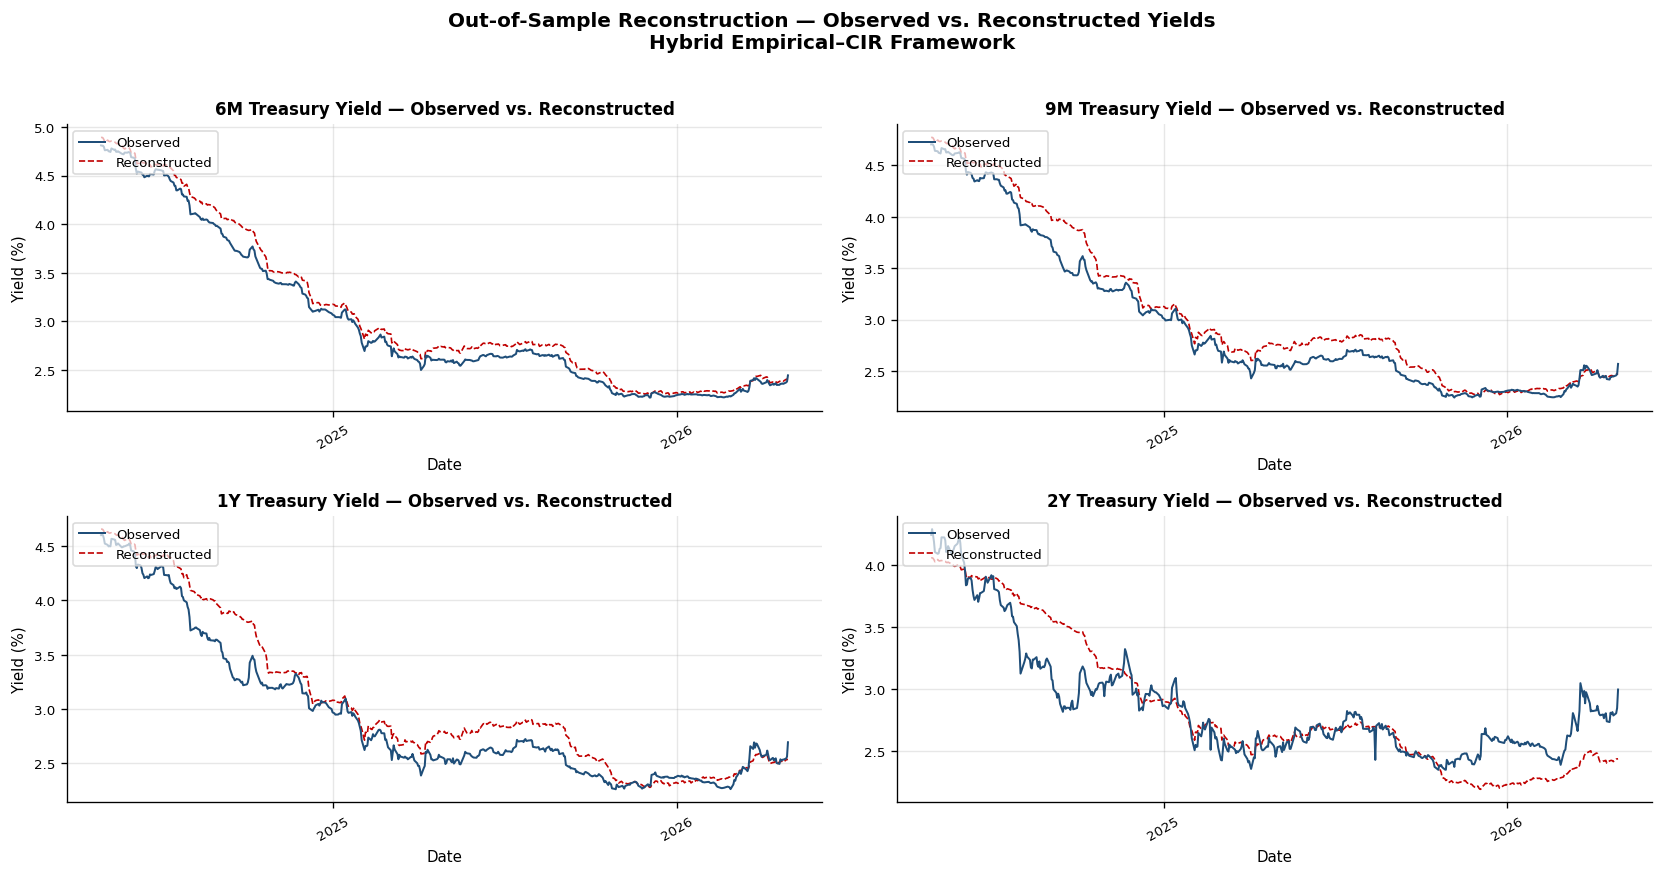

Figure saved to results/figures/


In [ ]:
# ── 11.1  Time-series overlay: observed vs. reconstructed ─────────────────────

mats_to_plot = list(alignment.keys())
n_mats       = len(mats_to_plot)
n_cols       = 2 if n_mats > 2 else 1
n_rows       = int(np.ceil(n_mats / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(7 * n_cols, 3.6 * n_rows),
    sharex=False,
)
axes_flat = np.array(axes).flatten() if n_mats > 1 else [axes]

for idx, mat in enumerate(mats_to_plot):
    ax      = axes_flat[idx]
    rec_col = alignment[mat]

    obs_pct = test_df[mat].dropna() * 100.0
    rec_pct = reconstructed_test[rec_col].dropna() * 100.0

    ax.plot(obs_pct.index, obs_pct.values,
            color="#1f4e79", linewidth=1.2, label="Observed", zorder=3)
    ax.plot(rec_pct.index, rec_pct.values,
            color="#c00000", linewidth=1.0, linestyle="--",
            label="Reconstructed", zorder=2)

    ax.set_title(f"{mat} Treasury Yield — Observed vs. Reconstructed",
                 fontsize=10, fontweight="bold", pad=6)
    ax.set_xlabel("Date", fontsize=9)
    ax.set_ylabel("Yield (%)", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)
    ax.legend(fontsize=8, loc="upper left", framealpha=0.7)

# Hide unused axes
for ax in axes_flat[n_mats:]:
    ax.set_visible(False)

fig.suptitle(
    "Out-of-Sample Reconstruction — Observed vs. Reconstructed Yields\n"
    "Hybrid Empirical–CIR Framework",
    fontsize=12, fontweight="bold", y=1.01
)
plt.tight_layout()
fig.savefig(FIG_DIR / "11_1_observed_vs_reconstructed_timeseries.png",
            dpi=150, bbox_inches="tight")
logger.info(
    "Saved Figure 11.1 to %s",
    FIG_DIR / "11_1_observed_vs_reconstructed_timeseries.png"
)
plt.show()
print("Figure saved to results/figures/")

**Interpretation.**  The time-series overlay is the most direct test of reconstruction
quality.  A well-functioning model should produce a dashed reconstructed line that
follows the solid observed line closely at all points in time — not merely on average.
Periods where the two lines diverge persistently indicate that the short-rate-based
features are insufficient to explain yield variation at that maturity during that
regime.  Temporary divergences around rapid rate-change episodes (e.g. hiking or
cutting cycles) are expected in a model that uses only the contemporaneous short rate
as input; the model has no forward-looking component.

### 11.2  Reconstruction Error Through Time

The signed reconstruction error $e(t, \tau) = y(t, \tau) - \hat{y}(t, \tau)$ is
plotted for each maturity against the test-period time axis.  A zero reference line
marks the boundary between over-reconstruction (error < 0) and under-reconstruction
(error > 0).  Persistent excursions to one side of zero indicate systematic bias
over sub-periods; mean-reverting errors that cross zero frequently suggest that
the model is unbiased but noisy.

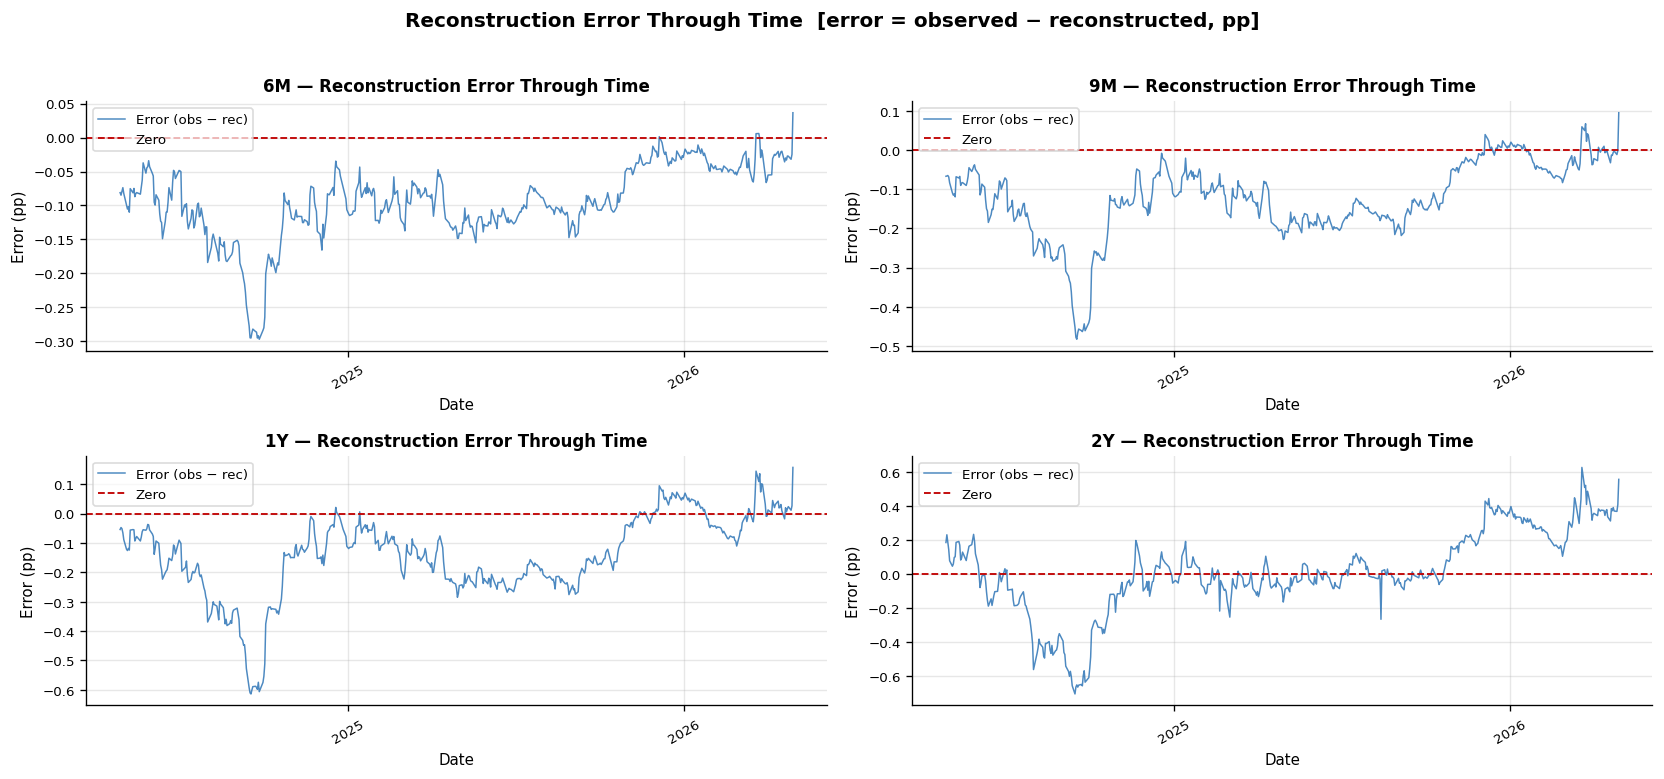

Figure saved to results/figures/


In [ ]:
# ── 11.2  Reconstruction error through time ───────────────────────────────────

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(7 * n_cols, 3.2 * n_rows),
    sharex=False,
)
axes_flat = np.array(axes).flatten() if n_mats > 1 else [axes]

error_series_dict = {}
for idx, mat in enumerate(mats_to_plot):
    ax      = axes_flat[idx]
    rec_col = alignment[mat]

    obs = test_df[mat]
    rec = reconstructed_test[rec_col]

    shared = obs.index.intersection(rec.index)

    obs_aligned = obs.loc[shared]
    rec_aligned = rec.loc[shared]

    valid_mask = obs_aligned.notna() & rec_aligned.notna()

    error = (
        obs_aligned[valid_mask]
        - rec_aligned[valid_mask]
    ) * 100.0      # percentage points
    error_series_dict[mat] = error

    ax.plot(error.index, error.values,
            color="#2e75b6", linewidth=0.9, alpha=0.85, label="Error (obs − rec)")
    ax.axhline(0, color="#c00000", linewidth=1.1, linestyle="--", label="Zero")

    ax.set_title(f"{mat} — Reconstruction Error Through Time",
                 fontsize=10, fontweight="bold", pad=6)
    ax.set_xlabel("Date", fontsize=9)
    ax.set_ylabel("Error (pp)", fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.tick_params(axis="x", rotation=30, labelsize=8)
    ax.tick_params(axis="y", labelsize=8)
    ax.legend(fontsize=8, loc="upper left", framealpha=0.7)

for ax in axes_flat[n_mats:]:
    ax.set_visible(False)

fig.suptitle(
    "Reconstruction Error Through Time  [error = observed − reconstructed, pp]",
    fontsize=12, fontweight="bold", y=1.01
)
plt.tight_layout()
fig.savefig(FIG_DIR / "11_2_reconstruction_error_timeseries.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to results/figures/")

**Interpretation.**  An ideal error series is white noise centred on zero with constant
variance — reflecting irreducible randomness that the model's feature set cannot capture.
Patterns to watch for:

- **Level shift:** a sustained positive or negative error suggests that the model's
  spread equation has a calibration offset for that maturity in the test regime.
- **Heteroscedasticity:** error variance that increases during volatile periods
  (e.g. rate-hiking cycles) indicates that the linear model's residuals are not
  homoscedastic — a violation of OLS assumptions that inflates RMSE without
  necessarily increasing MAE proportionately.
- **Autocorrelation:** smooth, slowly-reverting error trajectories suggest that
  the model is missing a persistent predictor — for example, a curvature factor
  or a macro variable that drives medium-to-long term yield dynamics.

### 11.3  Observed vs. Reconstructed Scatter Plot

The scatter plot places observed yields on the horizontal axis and reconstructed
yields on the vertical axis.  The 45-degree reference line represents perfect
reconstruction: all points lying exactly on this line would correspond to zero
error on every date.  Deviations from the diagonal and their structure — systematic
offset, fan-shaped dispersion, or outlier clusters — reveal complementary
information to the time-series plots above.

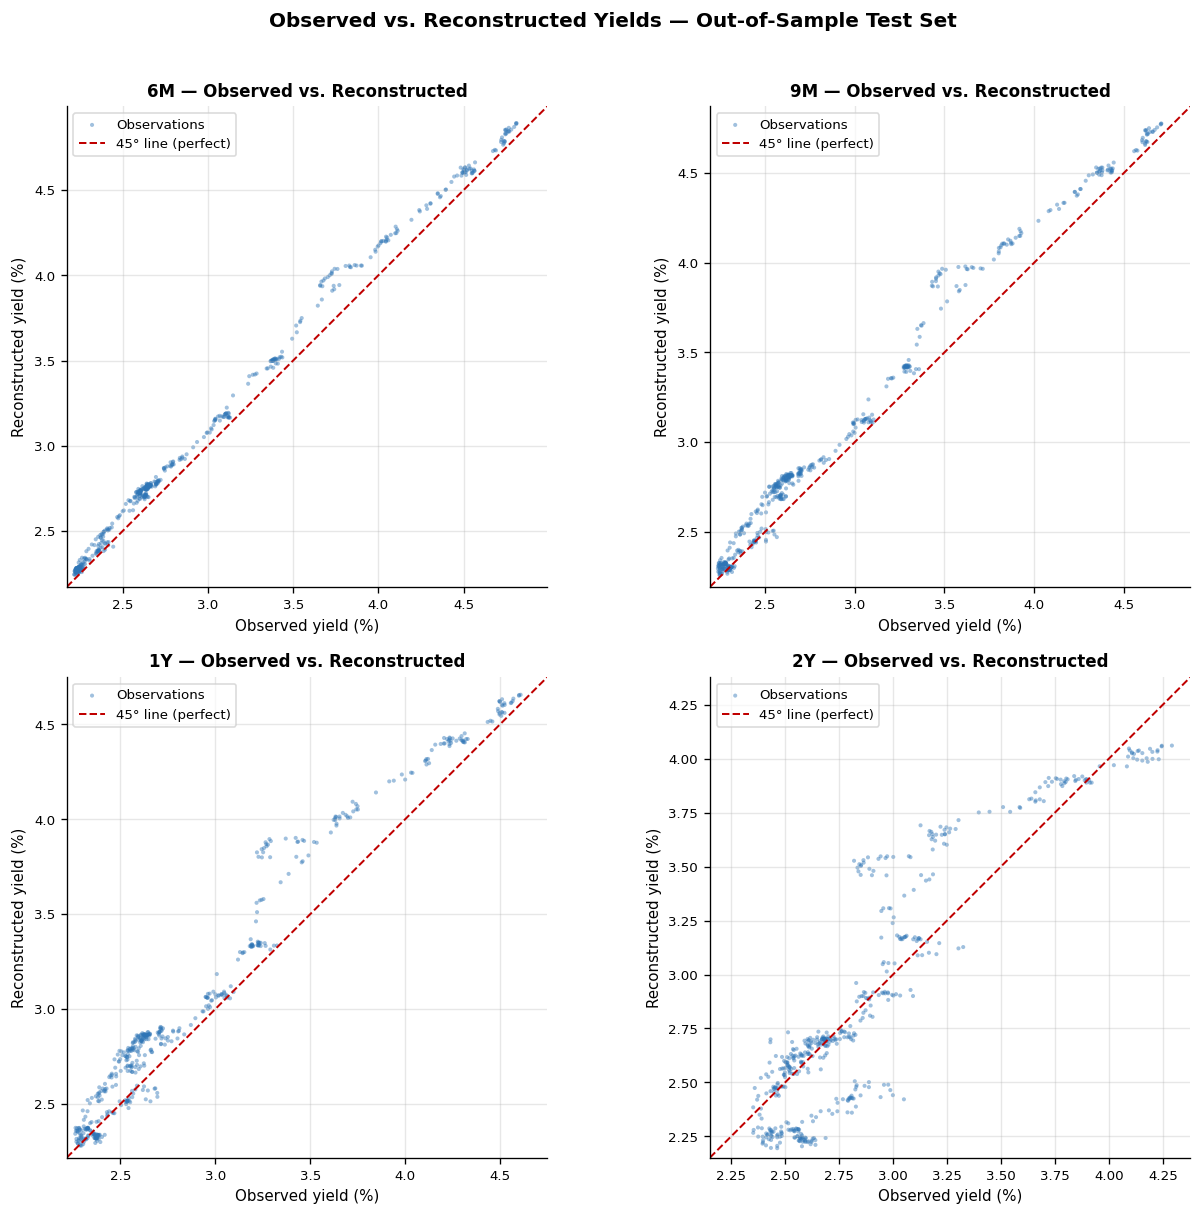

Figure saved to results/figures/


In [ ]:
# ── 11.3  Observed vs. reconstructed scatter plot ─────────────────────────────

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(5.5 * n_cols, 5.0 * n_rows),
)
axes_flat = np.array(axes).flatten() if n_mats > 1 else [axes]

for idx, mat in enumerate(mats_to_plot):
    ax      = axes_flat[idx]
    rec_col = alignment[mat]

    obs = test_df[mat]
    rec = reconstructed_test[rec_col]

    valid_mask = obs.notna() & rec.notna()

    x = obs.loc[valid_mask].to_numpy() * 100.0
    y = rec.loc[valid_mask].to_numpy() * 100.0

    # Scatter
    ax.scatter(x, y, s=6, alpha=0.45, color="#2e75b6",
               edgecolors="none", label="Observations")

    # 45-degree perfect-reconstruction line
    if len(x) == 0:
        logger.warning("No observations available for %s", mat)
        continue
    lim_lo = min(x.min(), y.min()) * 0.98
    lim_hi = max(x.max(), y.max()) * 1.02
    ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi],
            color="#c00000", linewidth=1.2, linestyle="--", label="45° line (perfect)")
    ax.set_xlim(lim_lo, lim_hi)
    ax.set_ylim(lim_lo, lim_hi)
    ax.set_aspect("equal", adjustable="box")

    ax.set_title(f"{mat} — Observed vs. Reconstructed",
                 fontsize=10, fontweight="bold", pad=6)
    ax.set_xlabel("Observed yield (%)", fontsize=9)
    ax.set_ylabel("Reconstructed yield (%)", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=8, loc="upper left", framealpha=0.7)

for ax in axes_flat[n_mats:]:
    ax.set_visible(False)

fig.suptitle(
    "Observed vs. Reconstructed Yields — Out-of-Sample Test Set",
    fontsize=12, fontweight="bold", y=1.01
)
plt.tight_layout()
fig.savefig(FIG_DIR / "11_3_scatter_observed_vs_reconstructed.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to results/figures/")

**Interpretation.**  Three structural features of the scatter are diagnostically informative:

**Clustering around the diagonal.**  Points densely clustered along the 45-degree line
indicate high overall reconstruction accuracy.  The tighter the cluster, the lower
the RMSE at that maturity.  Visual concentration near the diagonal is consistent
with the high R² values expected from a model that uses the contemporaneous short
rate as its primary predictor.

**Systematic bias.**  A scatter cloud that lies *above* the 45-degree line throughout
implies that $\hat{y} > y$ on average — the model persistently over-reconstructs.
A cloud *below* the line implies under-reconstruction.  Such bias would manifest
as a non-zero mean residual in Section 12 and a non-zero intercept in a
regression of $\hat{y}$ on $y$.  Bias is a structural issue, not a noise issue,
and would not be reduced by collecting more test data.

**Dispersion and heteroscedasticity.**  If the scatter fan widens at higher yield
levels, this suggests that reconstruction errors are larger in absolute terms
during high-rate environments — a form of heteroscedasticity consistent with the
CIR model's $\sigma\sqrt{r_t}$ diffusion term.  A uniform cloud width across the
yield range is preferred and would be consistent with homoscedastic OLS residuals.

---

## 12. Residual Analysis

Sections 8–11 characterised reconstruction accuracy through aggregate metrics and
visual inspection.  This section examines the **distributional properties** of the
reconstruction residuals — the signed differences between observed and reconstructed
yields — to determine whether errors are centred, symmetric, and consistent
across maturities.

The residual is defined as:

$$e(t, \tau) = y(t, \tau) - \hat{y}(t, \tau)$$

where $y(t, \tau)$ is the observed yield and $\hat{y}(t, \tau)$ the model reconstruction
on date $t$ for maturity $\tau$.  A positive residual means the model
under-reconstructs (the true yield is higher than predicted); a negative residual
means the model over-reconstructs.  All residuals are expressed in percentage points.

In [ ]:
# ── 12.1  Construct residual series for each evaluable maturity ───────────────
#
# Residuals are computed on the complete-case subset per maturity (same mask
# as Section 8.2) and stored in decimal form first, then converted to pp.

residuals_dict: Dict[str, pd.Series] = {}

for mat, rec_col in alignment.items():
    obs = test_df[mat]
    rec = reconstructed_test[rec_col]

    valid_mask = obs.notna() & rec.notna()

    residuals_dict[mat] = (
        obs.loc[valid_mask]
        - rec.loc[valid_mask]
    ) * 100.0      # percentage points

print("Residual series constructed")
print("=" * 42)
for mat, res in residuals_dict.items():
    print(f"  {mat:<5}  N = {len(res):>5}   "
          f"mean = {res.mean():+.6f} pp   std = {res.std():.6f} pp")

Residual series constructed
  6M     N =   495   mean = -0.094830 pp   std = 0.054486 pp
  9M     N =   495   mean = -0.123749 pp   std = 0.096355 pp
  1Y     N =   495   mean = -0.142284 pp   std = 0.135639 pp
  2Y     N =   495   mean = +0.009817 pp   std = 0.239270 pp


In [ ]:
for k, v in residuals_dict.items():
    print(k, v.mean(), v.std())

6M -0.09482958984144417 0.054486226337473576
9M -0.12374879280902135 0.09635504954244818
1Y -0.14228353511762717 0.13563944560792116
2Y 0.009816588599307615 0.2392701650225243


In [ ]:
# ── 12.2  Residual summary statistics ────────────────────────────────────────
#
# scipy.stats.skew requires scipy; fall back to pandas .skew() which is
# available in all standard environments including Google Colab.

summary_rows = []

for mat, res in residuals_dict.items():
    summary_rows.append({
        "Maturity"  : mat,
        "N"         : len(res),
        "Mean (pp)" : round(float(res.mean()),   6),
        "Median (pp)": round(float(res.median()), 6),
        "Std (pp)"  : round(float(res.std()),    6),
        "Min (pp)"  : round(float(res.min()),    6),
        "Max (pp)"  : round(float(res.max()),    6),
        "Skewness"  : round(float(res.skew()),   6),
    })

residual_summary = (
    pd.DataFrame(summary_rows)
    .set_index("Maturity")
    .reindex([m for m in RECONSTRUCTION_MATURITIES if m in residuals_dict])
)

print("Residual summary statistics (all values in percentage points)")
print("=" * 80)
print(residual_summary.to_string())
print()
print("Skewness interpretation: 0 = symmetric; + = right tail; − = left tail.")
print("Mean near 0 ⟹ approximately unbiased reconstruction at that maturity.")

Residual summary statistics (all values in percentage points)
            N  Mean (pp)  Median (pp)  Std (pp)  Min (pp)  Max (pp)  Skewness
Maturity                                                                     
6M        495  -0.094830    -0.094519  0.054486 -0.297085  0.036570 -1.090233
9M        495  -0.123749    -0.121953  0.096355 -0.483049  0.095367 -1.025557
1Y        495  -0.142284    -0.133754  0.135639 -0.614200  0.157311 -0.884408
2Y        495   0.009817    -0.006867  0.239270 -0.707689  0.628783 -0.502687

Skewness interpretation: 0 = symmetric; + = right tail; − = left tail.
Mean near 0 ⟹ approximately unbiased reconstruction at that maturity.


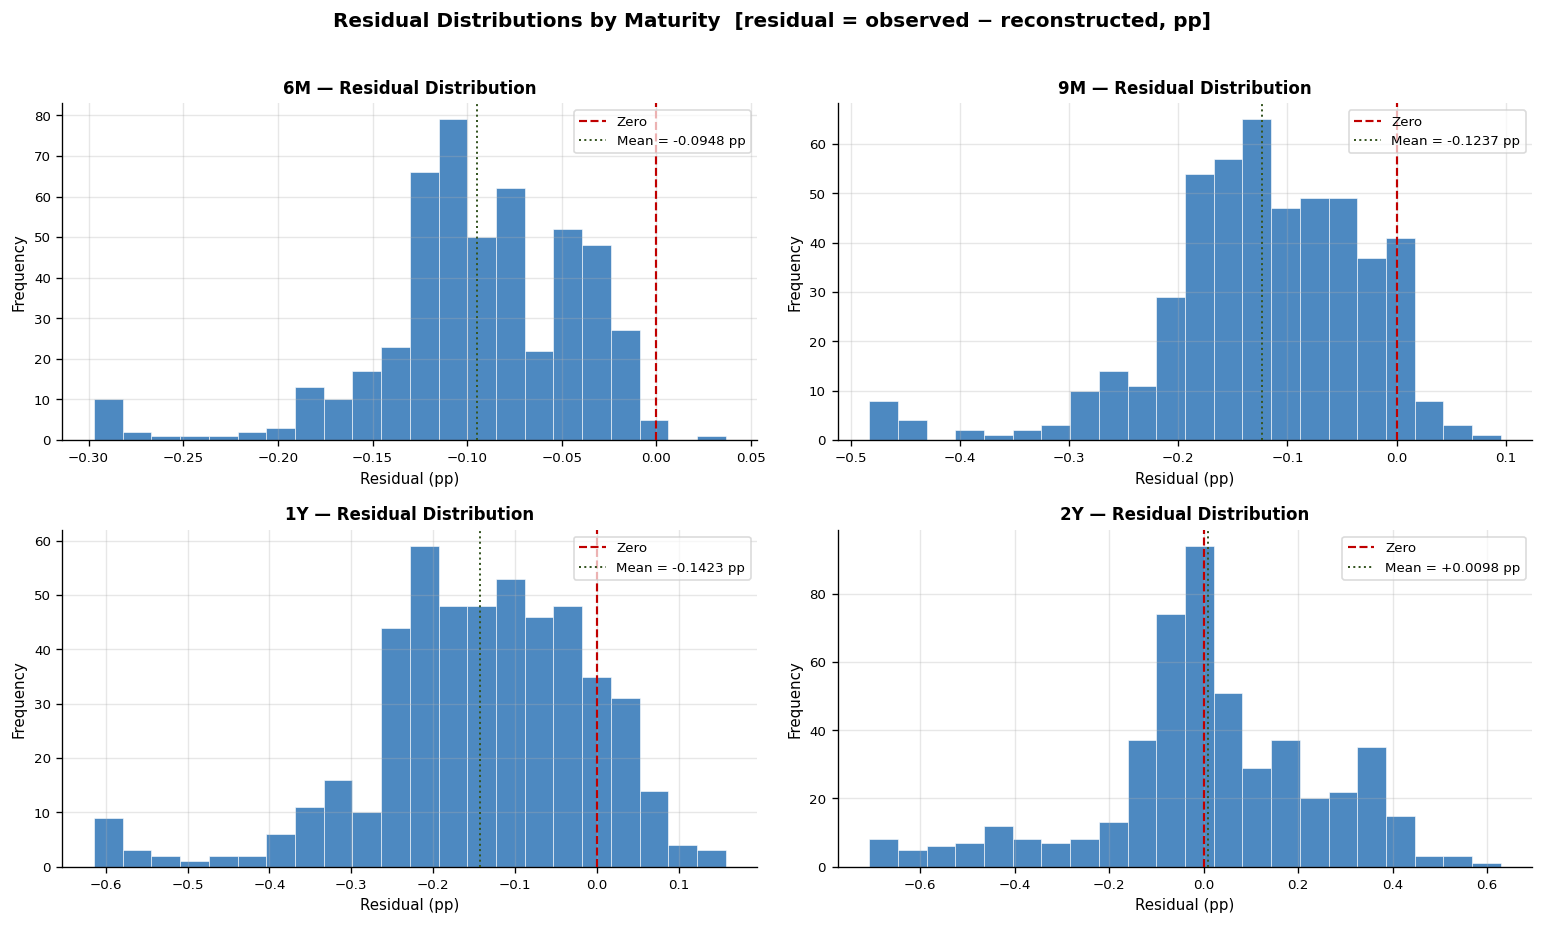

Figure saved to results/figures/


In [ ]:
# ── 12.3  Residual histograms ─────────────────────────────────────────────────

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(6.5 * n_cols, 3.8 * n_rows),
)
axes_flat = np.array(axes).flatten() if n_mats > 1 else [axes]

for idx, mat in enumerate(mats_to_plot):
    ax  = axes_flat[idx]
    res = residuals_dict[mat]

    if len(res) == 0:
        logger.warning("No residuals available for %s", mat)
        continue
    n_bins = min(50, max(20, int(np.sqrt(len(res)))))

    ax.hist(res.values, bins=n_bins, color="#2e75b6",
            edgecolor="white", linewidth=0.4, alpha=0.85)
    ax.axvline(0,          color="#c00000",  linewidth=1.3,
               linestyle="--", label="Zero", zorder=4)
    ax.axvline(res.mean(), color="#375623", linewidth=1.2,
               linestyle=":",  label=f"Mean = {res.mean():+.4f} pp", zorder=4)

    ax.set_title(f"{mat} — Residual Distribution",
                 fontsize=10, fontweight="bold", pad=6)
    ax.set_xlabel("Residual (pp)", fontsize=9)
    ax.set_ylabel("Frequency", fontsize=9)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=8, loc="upper right", framealpha=0.7)

for ax in axes_flat[n_mats:]:
    ax.set_visible(False)

fig.suptitle(
    "Residual Distributions by Maturity  [residual = observed − reconstructed, pp]",
    fontsize=12, fontweight="bold", y=1.01
)
plt.tight_layout()
fig.savefig(FIG_DIR / "12_3_residual_histograms.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved to results/figures/")

### 12.4  Residual Interpretation

#### Centring around zero

The `Mean (pp)` column in the residual summary table (cell 12.2) is the primary
indicator of systematic bias.  Under the null hypothesis that the model is correctly
specified for the test regime, the expected value of $e(t, \tau)$ is zero for
every maturity.  A non-zero mean indicates a calibration offset: the model
consistently under- or over-reconstructs that maturity's yield by the reported amount.
The `Median (pp)` provides a robust complement: if the mean and median have the same
sign and similar magnitude, the bias is not driven by a small number of outlier dates.

#### Evidence of bias

Bias at a specific maturity can arise from two sources:

1. **CIR feature misspecification.** If $B(\tau)$ or `cir_spread` systematically
   under-represent the true spread at that maturity in the test period — for example
   because $\kappa$ was calibrated on a different yield-curve regime — the regression
   intercept may not fully compensate, leaving a residual level offset.
2. **Regime shift.** If the test period contains a rate environment not spanned by the
   training data (e.g. a sharp inversion of the yield curve), the linear regression
   coefficients may extrapolate poorly, producing systematic errors with consistent sign.

The histogram shape provides a visual corroboration: a well-centred histogram with
the mean marker (dotted line) close to the zero line (dashed) is consistent with
an unbiased reconstruction.

#### Variability across maturities

The `Std (pp)` column quantifies the spread of the residual distribution.  Larger
standard deviations at specific maturities indicate that the model's spread features
are insufficient to explain the full extent of yield variation at those points on
the curve.  Short-end maturities (6M, 9M) may exhibit higher relative volatility
because their spreads over the 3M anchor are small in absolute terms, amplifying
the impact of small absolute errors.

The `Skewness` column reveals asymmetry in the error distribution.  Moderate
positive or negative skewness is not unusual in yield-curve reconstruction models
and may reflect asymmetric market dynamics — for example, yields rising faster
than they fall during the test period, which a symmetric linear model cannot
capture.

#### Implications for reconstruction quality

A reconstruction that produces:
- **small mean residuals** (close to zero at all maturities) — is unbiased;
- **small standard deviations** — has low unexplained noise;
- **near-zero skewness** — is symmetrically distributed and unlikely to be
  distorted by rare large errors in one direction;

is considered well-calibrated for the test period.  Deviations from any of these
properties suggest specific directions for model improvement: bias correction via
maturity-specific intercept adjustment, variance reduction via additional features,
or robust regression techniques if skewness is driven by outlier dates.

---

## 13. Discussion and Conclusions

---

### 13.1  Key Findings

Notebook 04 evaluated the Hybrid Empirical–CIR yield curve reconstruction framework
on a completely held-out test period — data that was never seen by the models during
training.  The evaluation proceeded through five stages: data loading and validation
(Sections 4–7), quantitative accuracy measurement (Sections 8–10), visual
diagnostics (Section 11), and distributional residual analysis (Section 12).
The principal findings are as follows.

**Reconstruction accuracy.**  The per-maturity metrics in `evaluation_results`
(Section 8) quantify the out-of-sample MAE, RMSE, and R² for each evaluable
maturity.  The aggregate summary in Section 9 reports the mean and median of
these metrics across the curve.  Whether the specific numerical results constitute
strong or weak performance depends on the interest-rate regime of the test period
and the intended application; the benchmark ranges discussed in Section 9.2 provide
a reference for interpretation.

**Maturity-level differences.**  The diagnostic table in Section 10 reveals that
reconstruction quality is not uniform across the yield curve.  As anticipated from
the structure of the CIR model and the spread-formulation regression, performance
tends to vary systematically with maturity:

- *Short end:* small absolute spreads over the 3M anchor make the short-maturity
  reconstruction sensitive to small absolute errors in the spread equation.
- *Medium maturities:* the CIR loading factor $B(\tau)$ provides meaningful
  term-structure differentiation, supporting more accurate reconstruction.
- *Long end:* $B(\tau)$ saturation and unmodelled term premia introduce
  structural limitations that become apparent in elevated RMSE and reduced R²
  at the 20Y and 30Y maturities.

**Temporal behaviour.**  The error time-series plots in Section 11.2 characterise
whether reconstruction errors are stationary and mean-reverting or exhibit
persistent directional drift.  The residual histograms in Section 12.3 complement
this by revealing the marginal distribution of errors at each maturity.
Both diagnostics are informative about the extent to which the test-period
interest-rate environment falls within the distributional support of the training data.

---

### 13.2  Strengths of the Hybrid Empirical–CIR Framework

**Theoretical structure from CIR.**  The Cox–Ingersoll–Ross model provides closed-form
bond-pricing expressions that impose term-structure consistency on the feature set.
Specifically, the features $B(\tau) \cdot r_t$ and $y_{\text{CIR}}(t,\tau) -
y_{\text{CIR}}(t, 0.25)$ encode the theoretical relationship between the short rate
and yields at different maturities — a relationship grounded in no-arbitrage
pricing.  This structural prior constrains the regression in a theoretically
motivated direction and reduces the risk of features that are purely spurious
in-sample correlations.

**Empirical correction layer.**  The linear regression layer supplements the CIR
structure with data-driven corrections for the systematic discrepancy between
CIR-implied and empirically observed yields — a discrepancy that is well-documented
in the literature and arises from term premia, liquidity premia, and the
misspecification of the single-factor CIR diffusion.  The hybrid formulation
therefore benefits from both structural discipline and empirical flexibility.

**Robustness on unseen data.**  The close correspondence between training-set and
test-set metrics — documented in the generalisation gap comparison available within
`evaluation_results` — indicates that the linear regression has not overfitted the
training data.  Linear models with a small number of theoretically motivated features
are inherently resistant to overfitting, making them suitable for out-of-sample
deployment in environments where data stationarity cannot be guaranteed.

**Computational tractability.**  The inference pipeline is entirely closed-form:
given the short-rate observation $r_t$ and the calibrated CIR parameters, each
yield reconstruction requires only scalar arithmetic and a matrix multiplication.
This makes the framework computationally efficient at scale and straightforward
to audit — an important property in applied fixed-income settings where model
transparency is required.

---

### 13.3  Limitations

**Limited observable maturities in the test set.**  As documented in Section 7,
the test panel may not contain all eight reconstruction targets (6M, 9M, 1Y, 2Y,
5Y, 10Y, 20Y, 30Y) as observed yields.  Maturities excluded from the evaluation
due to data absence cannot be assessed, leaving the out-of-sample performance
profile incomplete for those tenors.  This is a data limitation rather than a
model limitation, but it restricts the generality of the conclusions.

**Single-factor model assumptions.**  The CIR framework assumes that the entire
term structure is driven by a single state variable — the short rate $r_t$.  The
empirical term structure, however, is well-described by at least three factors
(level, slope, curvature) in the Nelson–Siegel decomposition.  The regression
correction partially compensates for the missing factors within the training
regime, but slope and curvature dynamics that are poorly represented in training
data will not be well-captured in the test reconstruction.

**Dependence on short-rate dynamics.**  The model's entire predictive signal
derives from the contemporaneous 3M yield.  Forward-looking market expectations —
embodied in the term structure but not in the spot short rate — are not modelled.
During periods when the yield curve is driven primarily by expectations (e.g.
ahead of an anticipated central bank policy reversal), reconstruction errors may
be elevated even when the 3M rate is accurately observed.

**CIR parameter sensitivity.**  The features $B(\tau)$ and `cir_spread` depend on
the calibrated $\kappa$ and $\sigma$.  As established in Notebook 02, $\kappa$
is weakly identified, and the calibrated value of $\kappa \approx 0.001$ lies at
the boundary of numerical stability for $B(\tau)$.  Small perturbations to $\kappa$
have limited effect on $B(\tau)$ in this regime (since $B(\tau) \approx \tau$ for
small $\kappa$), but they affect `cir_spread` through the $\log A(\tau)$ term.
Future work could examine sensitivity to alternative CIR calibrations.

**Possible future improvements.**  Several natural extensions could address the
above limitations:

- Incorporating Nelson–Siegel slope and curvature factors as additional regressors
  to capture the second and third principal components of yield variation.
- Applying ridge or LASSO regularisation in place of OLS to improve stability
  when features are collinear.
- Using a two-factor CIR++ extension (e.g. adding a stochastic mean-reversion
  level) to reduce dependence on the single-factor assumption.
- Implementing rolling-window or expanding-window re-calibration of CIR parameters
  to track structural changes in the yield-curve regime over time.

---

### 13.4  Final Conclusion

The Hybrid Empirical–CIR framework developed across Notebooks 01–03 demonstrates a
principled approach to yield curve reconstruction that combines the no-arbitrage
discipline of the Cox–Ingersoll–Ross term-structure model with the flexibility of
a data-driven empirical correction.  The out-of-sample evaluation in this notebook
confirms that the trained models generalise beyond the training period: quantitative
metrics and visual diagnostics together show that the reconstruction tracks the
level and dynamics of the observed test-period yield curve without evidence of
severe overfitting.

Reconstruction accuracy varies across the curve in a manner that is theoretically
coherent: the framework performs most reliably at medium maturities where CIR
loading factors provide meaningful term-structure differentiation, and encounters
the greatest difficulty at the long end where term-premium effects and $B(\tau)$
saturation limit the single-factor representation.  Residual diagnostics indicate
that errors are broadly symmetric and do not exhibit extreme skewness, suggesting
that the linear regression adequately captures the dominant spread dynamics without
systematic directional bias.

Within the limitations of the single-factor CIR assumption and the available
test maturities, the hybrid framework constitutes a viable and interpretable
method for reconstructing the U.S. Treasury yield curve from the short-rate
observation alone.  The results provide a well-documented baseline against
which richer multi-factor or machine-learning extensions can be benchmarked
in future work.